<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Toulouse_public_library_loans_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toulouse public library loans dataset


# About the dataset

Toulouse public library, comprises 21,446 entries and 11 columns, offering a detailed look into library loans. Key columns include year, nb_loans (number of loans), title, author, publisher, classification, library, spine_label, audience, media_subtype, and media_type. Most columns are of object type, indicating categorical or string data, while year is a float and nb_loans is an integer.

From df.info() and df.isnull().sum(), we observe a few missing values: 2 in year, 1 in author, 5 in classification, and a more significant 4,244 in media_subtype. The nb_loans column, with no missing values, has a mean of approximately 139 loans and a maximum of 4907, suggesting a wide distribution in loan activity. The year column ranges from 2011 to 2024, with a mean of around 2017.6, indicating data collected over a decade.

Key insights from df.describe(include = 'all').T reveal that 'Alice au pays des merveilles' is the most frequent title, appearing 23 times. The most common publisher, author, and classification values are represented by a dash ('-'), which might indicate missing or unspecified data entries that need further investigation or cleaning. The primary library is 'CABANIS', accounting for 21,133 entries, and the dominant audience type is 'A' (12,593 entries). For media_type, 'cds' is the most common, while DVDFIC is the most frequent media_subtype among the non-null entries.

The absence of duplicate rows (df.duplicated().sum() returns 0) is a positive finding, suggesting good data integrity. Overall, the dataset provides a rich source for analyzing library loan patterns, popular titles, authors, and media types over the years. Future analysis could focus on handling missing values, standardizing categorical entries like author and publisher, and exploring trends in loans over time, across different libraries, and by audience segments. The imbalance in library and audience distribution could also be an interesting area for further study.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d grimespoint/toulouse-public-library-mdiathque-dataset

# Unziping the downloaded file
!unzip toulouse-public-library-mdiathque-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/grimespoint/toulouse-public-library-mdiathque-dataset
License(s): CC0-1.0
  0% 0.00/712k [00:00<?, ?B/s]
100% 712k/712k [00:00<00:00, 924MB/s]
Archive:  toulouse-public-library-mdiathque-dataset.zip
  inflating: toulouse_public_library_loans.csv  


In [8]:
df = pd.read_csv('toulouse_public_library_loans.csv', delimiter = ';')
df.head(11)

,year,nb_loans,title,author,publisher,classification,library,spine_label,audience,media_subtype,media_type
0,2023.0,207,Top Gun : Maverick,"Kosinski, Joseph","Boulogne-Billancourt : Paramount Pictures, 2022",AV TOPG,CABANIS,AV TOPG,A,DVDFIC,films
1,2023.0,193,Trois mille ans à t'attendre,"Miller, George","Paris : Metropolitan filmexport, 2023",F TROI,CABANIS,F TROI,A,DVDFIC,films
2,2023.0,152,Compétition officielle,"Cohn, Mariano","Paris : Wild side video, 2022",COMP,CABANIS,COMP,A,DVDFIC,films
3,2023.0,151,Licorice pizza,"Anderson, Paul Thomas","Paris : Universal Pictures Vidéo, 2022",LICO,CABANIS,LICO,A,DVDFIC,films
4,2023.0,144,Le discours,"Tirard, Laurent","Paris : Le Pacte, 2021",C DISC,CABANIS,C DISC,A,DVDFIC,films
5,2023.0,125,Là-haut,"Docter, Pete",Marne-la-Vallée : Pixar ; Buena Vista Home Ent...,A LAHA,CABANIS,A LAHA,E,DVDFIC,films
6,2023.0,124,EO,"Skolimowski, Jerzy","Paris : ARP Sélection, 2023",EO,CABANIS,EO,A,DVDFIC,films
7,2023.0,122,La belle et le clochard,"Luske, Hamilton","[S.l] : Buena Vista Home Intertainment, 2006",A BELL,CABANIS,A BELL,E,DVDFIC,films
8,2023.0,110,Ticket to Paradise,"Parker, Ol","Paris : Universal Pictures Vidéo, 2023",C TICK,CABANIS,C TICK,A,DVDFIC,films
9,2023.0,102,Les volets verts,"Becker, Jean","Paris : ARP Sélection, 2023",VOLE,CABANIS,VOLE,A,DVDFIC,films


In [9]:
df.tail(11)

,year,nb_loans,title,author,publisher,classification,library,spine_label,audience,media_subtype,media_type
21435,2024.0,16,A peu près,Pomme,-,S099.2,CABANIS,099.2 POM,A,NaN,cds
21436,2024.0,15,The String quartets,"Reich, Steve (1936-....)",-,S414.40,CABANIS,4 REI 14.40,A,NaN,cds
21437,2023.0,26,Les plus belles musiques classiques pour les e...,-,-,A 783 P,CABANIS,A 783 P,E,CD,cds
21438,2023.0,24,Sun monkey voltage,Rémi Panossian Trio,-,S100,CABANIS,1 PAN 70,A,CD,cds
21439,2023.0,23,We,Arcade Fire,-,S220,CABANIS,2 ARC 20,A,CD,cds
21440,2023.0,22,Iota,Lous And The Yakuza,-,S281,CABANIS,281 LOU,A,CD,cds
21441,2023.0,19,The Kick inside,"Bush, Kate",-,S220,CABANIS,2 BUS 20,A,CD,cds
21442,2023.0,19,Sometimes I might be introvert,Little Simz,-,S291,CABANIS,291 LIT,A,CD,cds
21443,2023.0,17,Metronomy forever,Metronomy,-,S294.5,CABANIS,294 MET 5,A,CD,cds
21444,2023.0,16,S&M 2,Metallica,-,S250,CABANIS,2 MET 50,A,CD,cds


In [10]:
df.shape

(21446, 11)

In [11]:
df.columns

Index(['year', 'nb_loans', 'title', 'author', 'publisher', 'classification',
       'library', 'spine_label', 'audience', 'media_subtype', 'media_type'],
      dtype='object')

In [12]:
df.dtypes

,0
year,float64
nb_loans,int64
title,object
author,object
publisher,object
classification,object
library,object
spine_label,object
audience,object
media_subtype,object


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21446 entries, 0 to 21445
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            21444 non-null  float64
 1   nb_loans        21446 non-null  int64  
 2   title           21446 non-null  object 
 3   author          21445 non-null  object 
 4   publisher       21446 non-null  object 
 5   classification  21441 non-null  object 
 6   library         21446 non-null  object 
 7   spine_label     21446 non-null  object 
 8   audience        21446 non-null  object 
 9   media_subtype   17202 non-null  object 
 10  media_type      21446 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1.8+ MB


In [14]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,21444.0,NaN,NaN,NaN,2017.616536,4.030371,2011.0,2014.0,2018.0,2021.0,2024.0
nb_loans,21446.0,NaN,NaN,NaN,139.064021,162.460018,12.0,45.0,132.0,182.0,4907.0
title,21446,9458,Alice au pays des merveilles,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author,21445,4094,-,2458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,21446,2611,-,6562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classification,21441,4066,S099.2,1119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
library,21446,9,CABANIS,21133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spine_label,21446,6075,E SAI,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
audience,21446,3,A,12593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
media_subtype,17202,19,DVDFIC,5529,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.isnull().sum()

,0
year,2
nb_loans,0
title,0
author,1
publisher,0
classification,5
library,0
spine_label,0
audience,0
media_subtype,4244


In [16]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

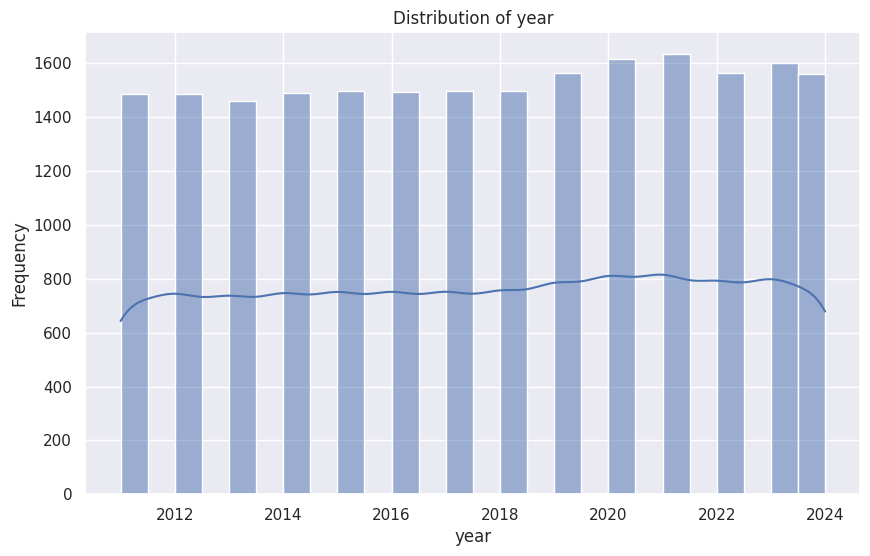

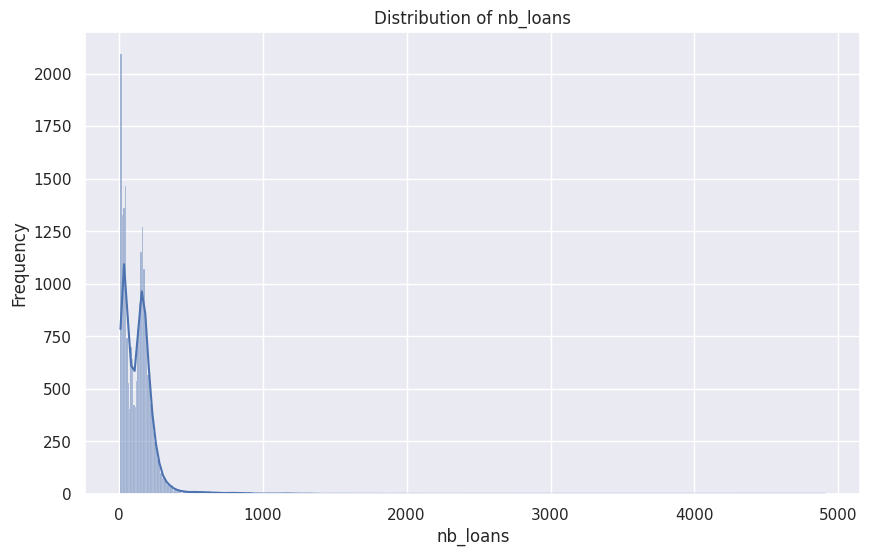

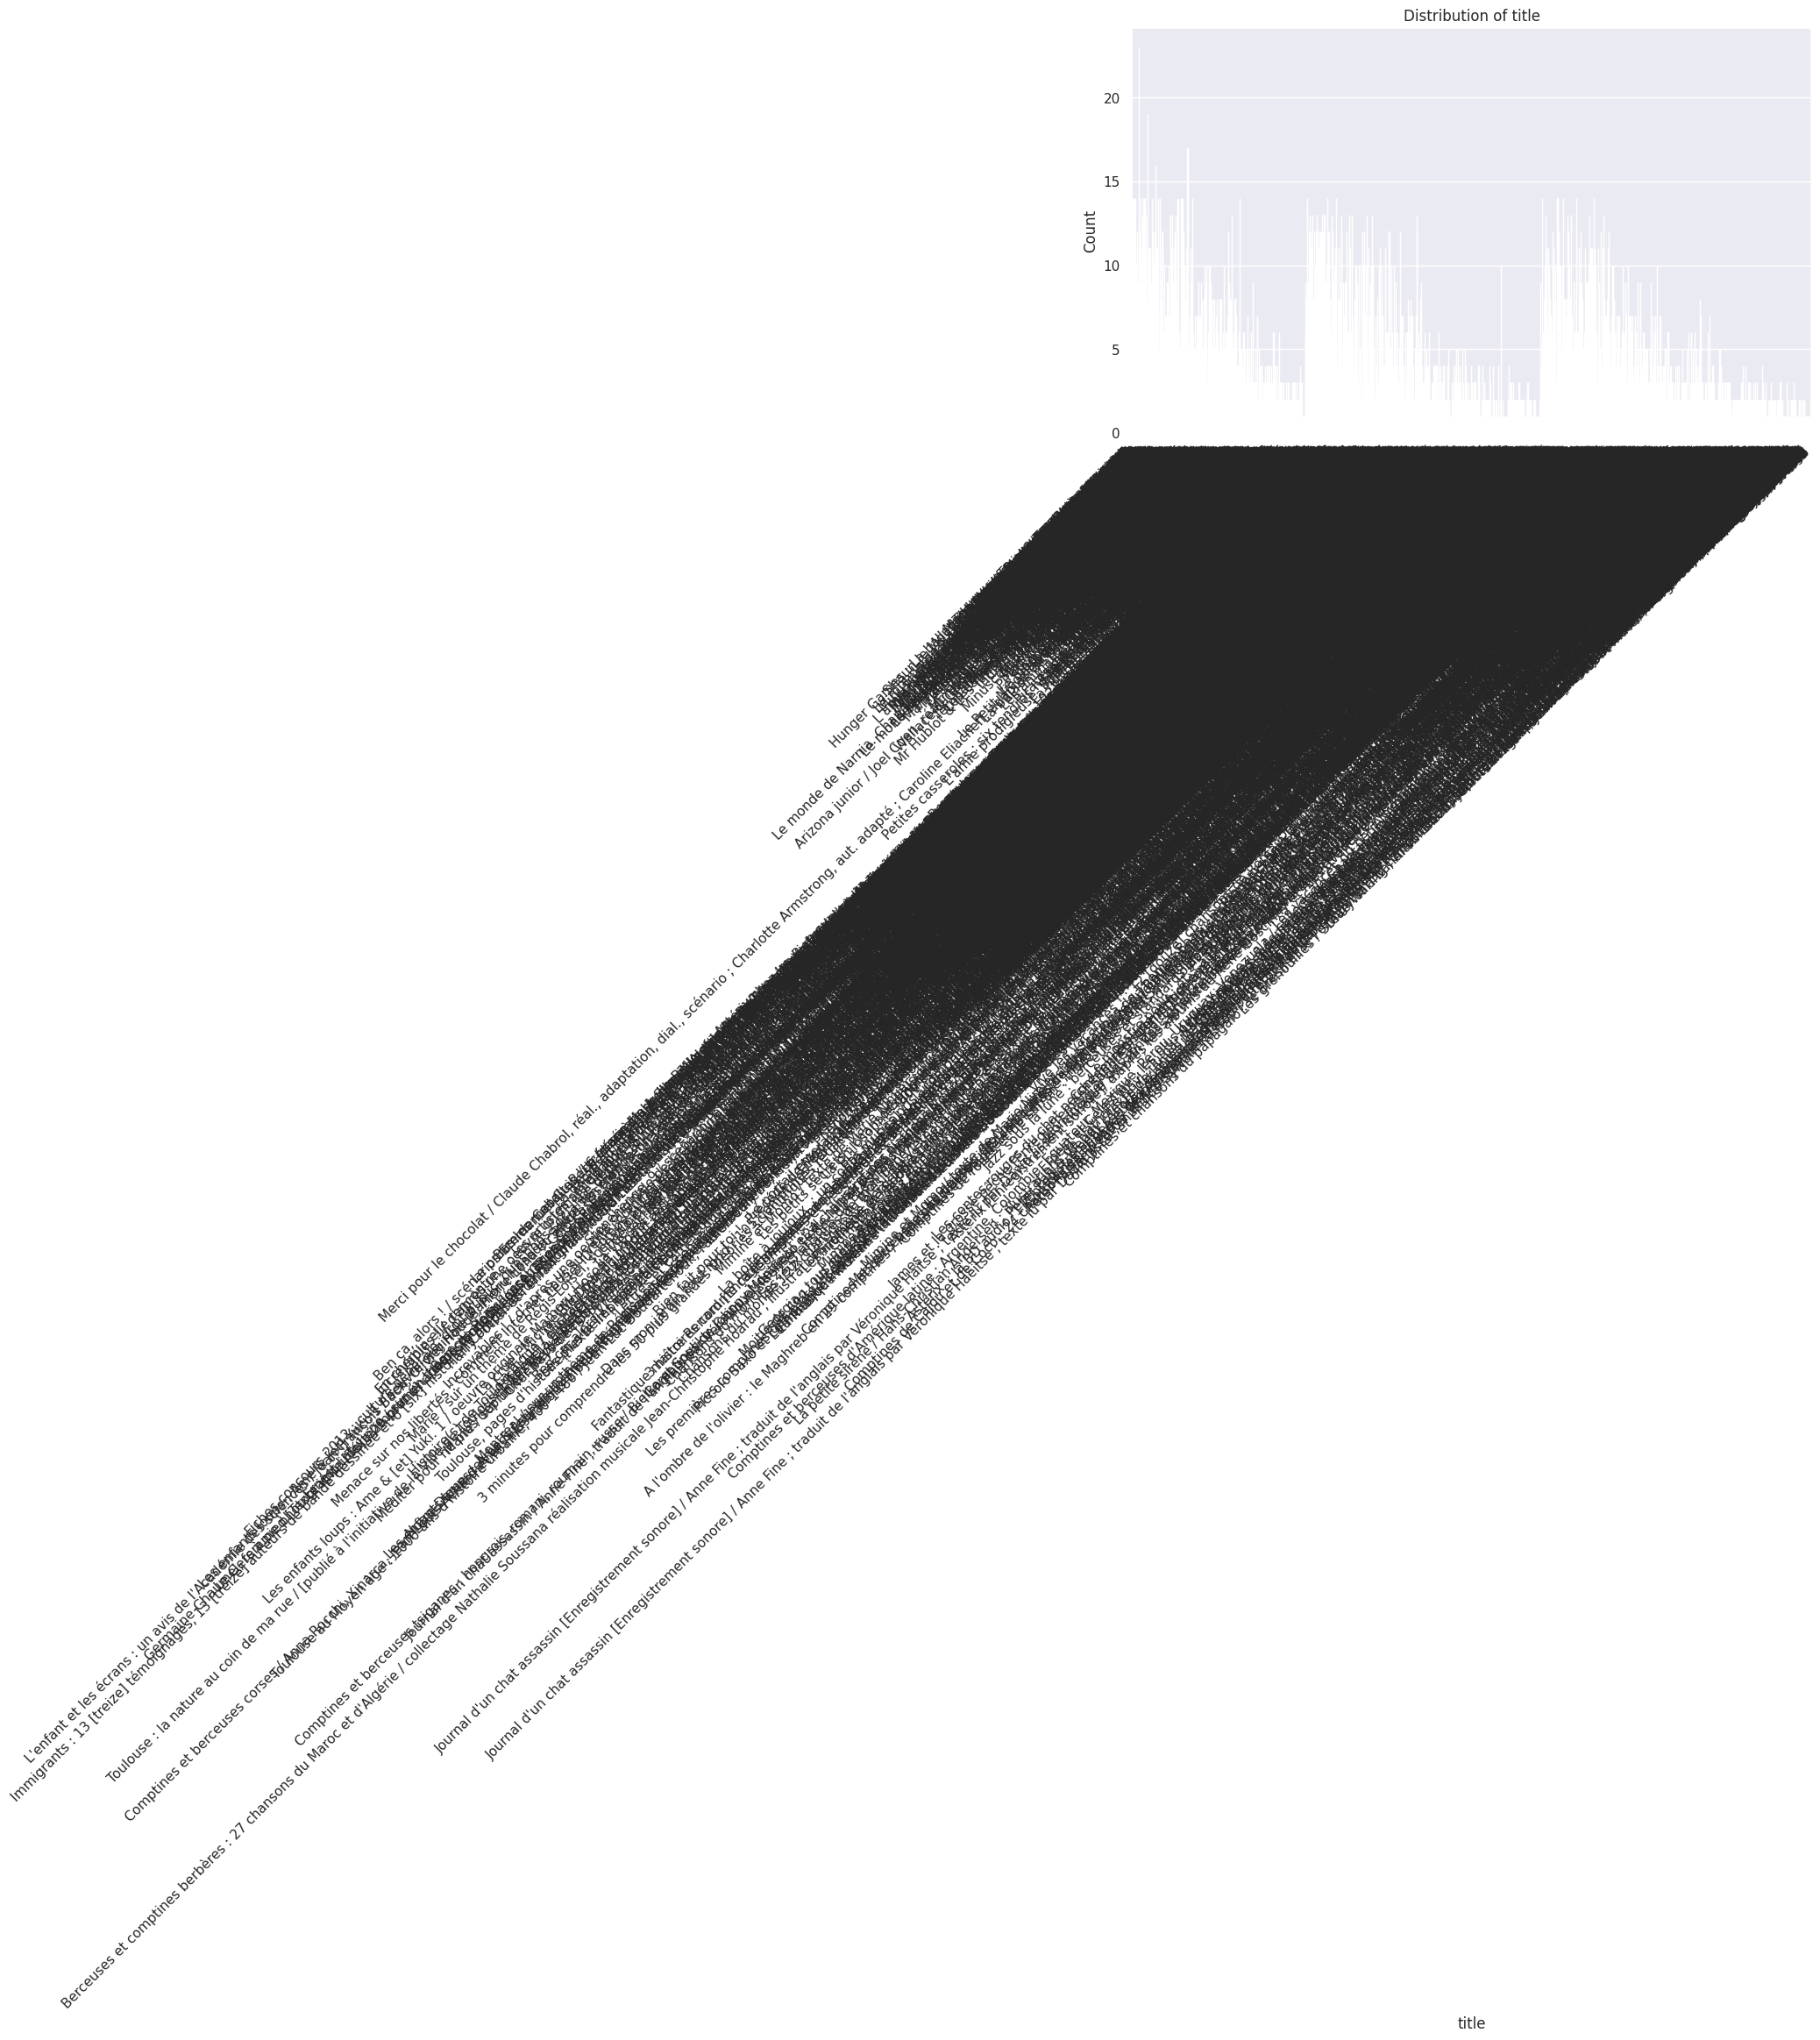

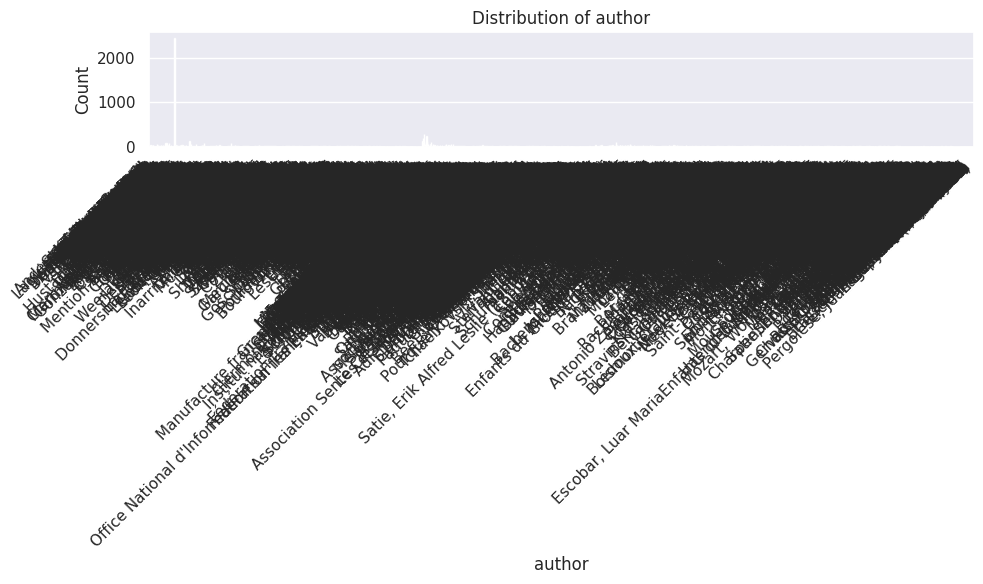

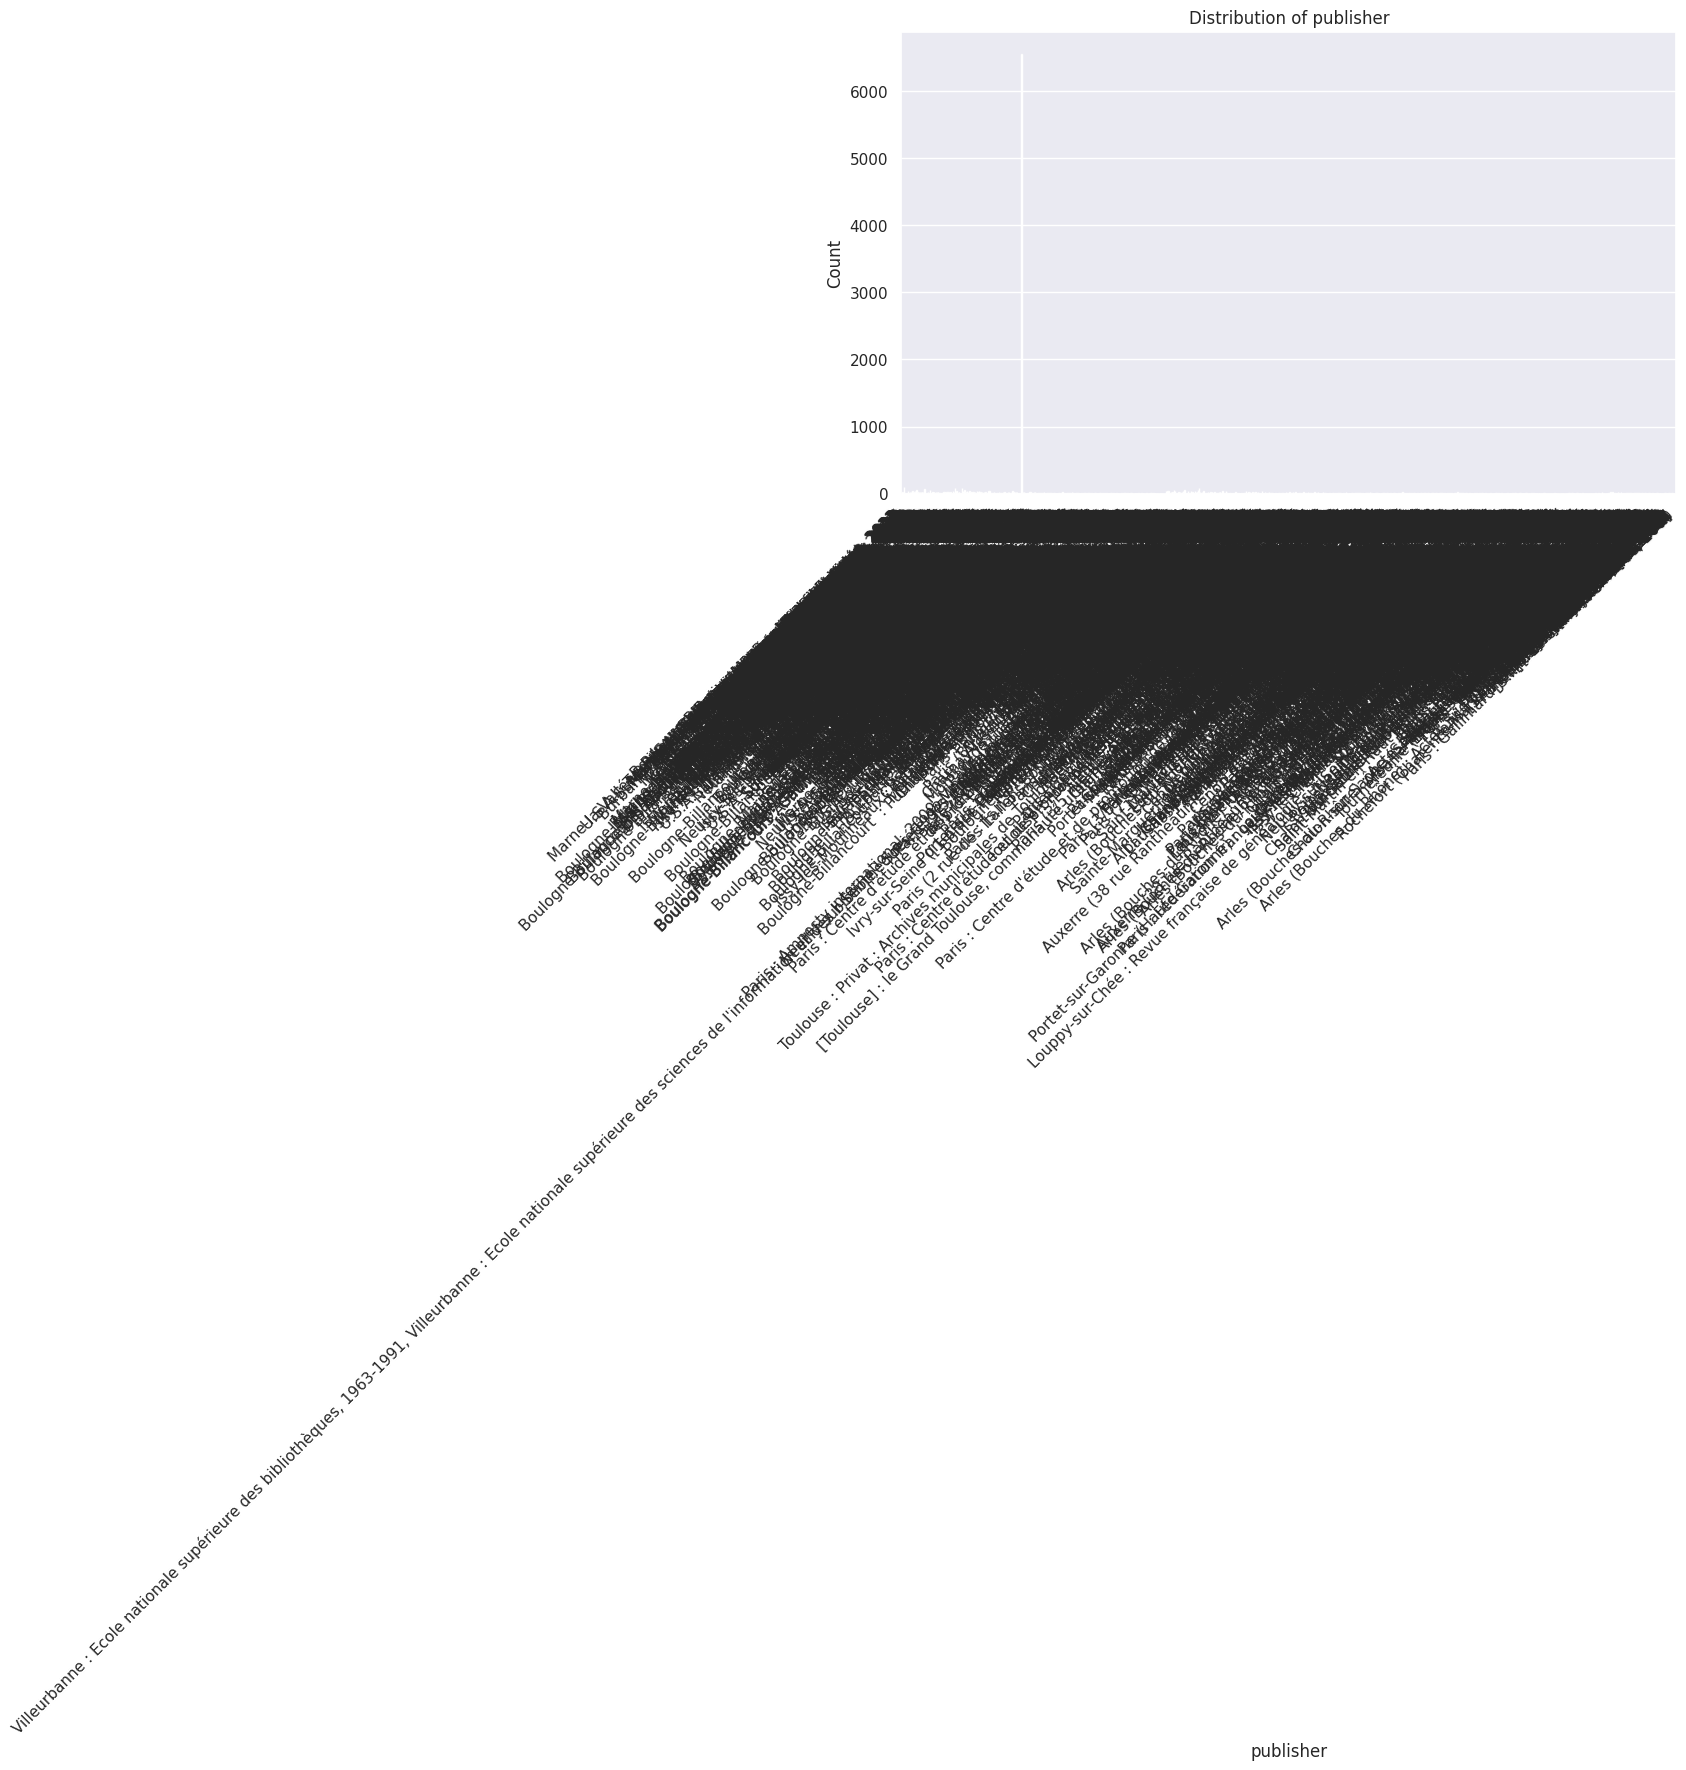

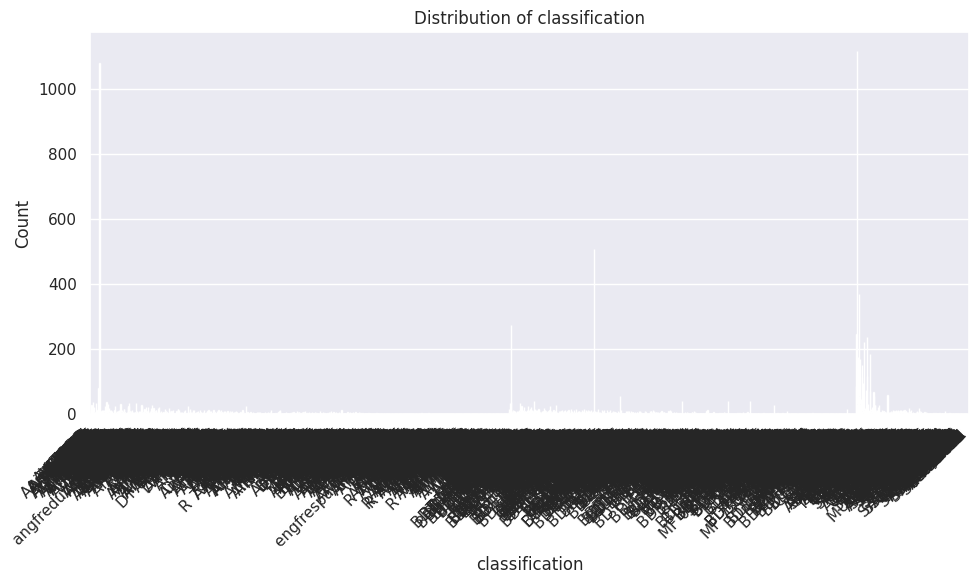

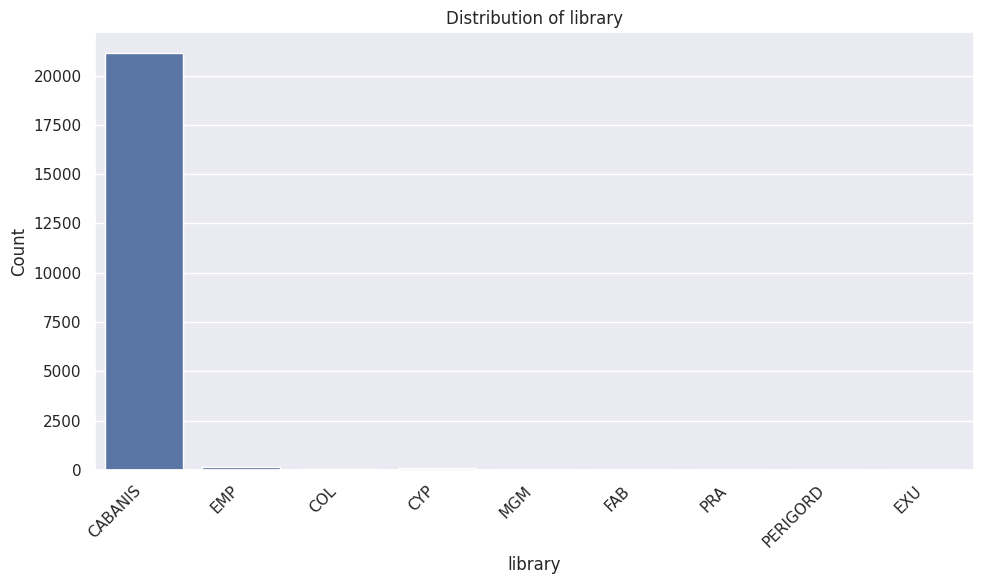

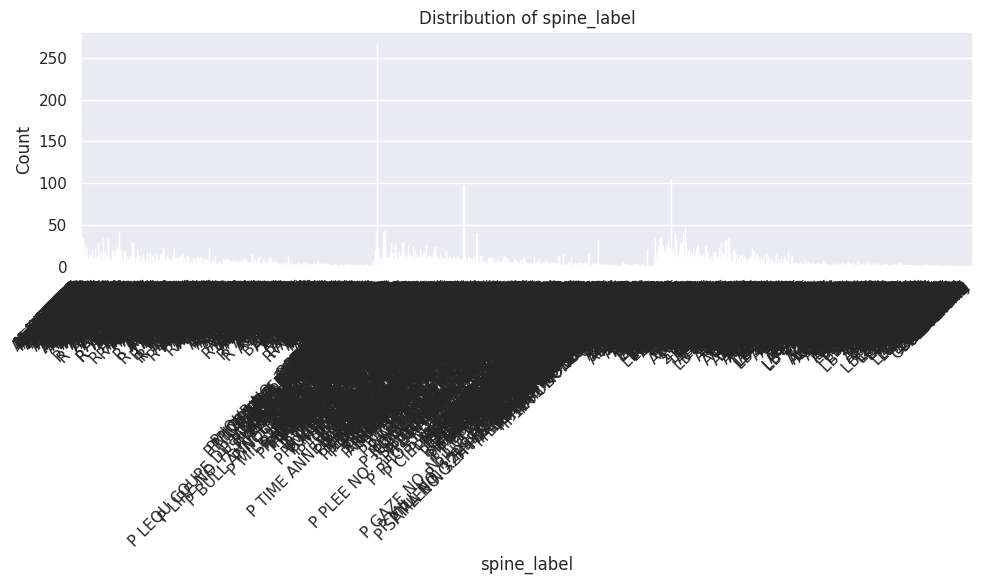

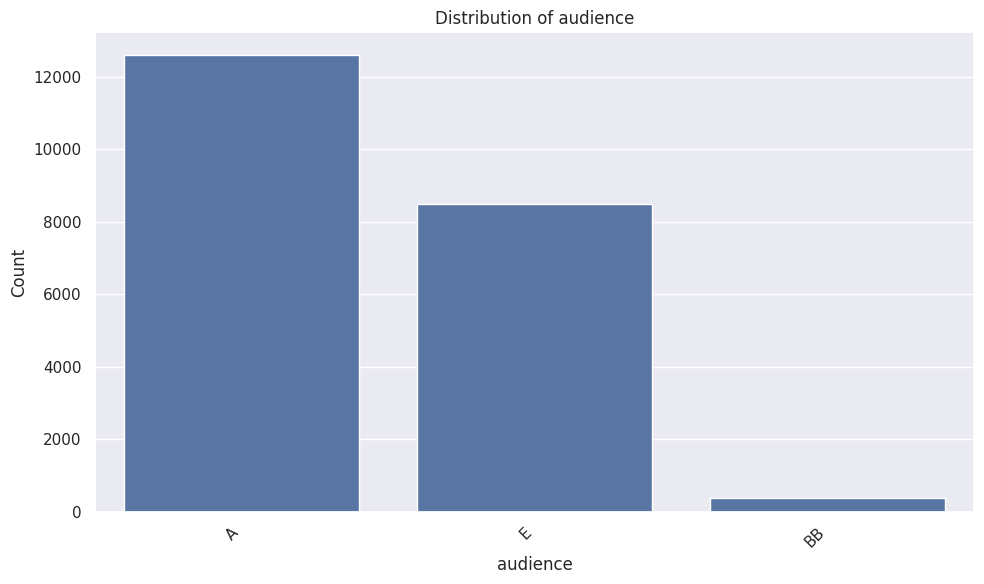

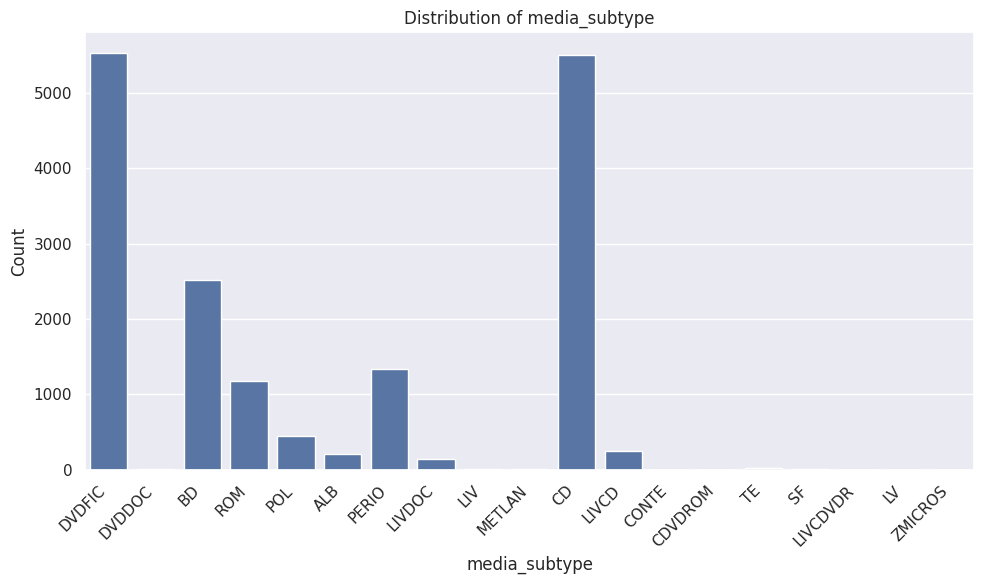

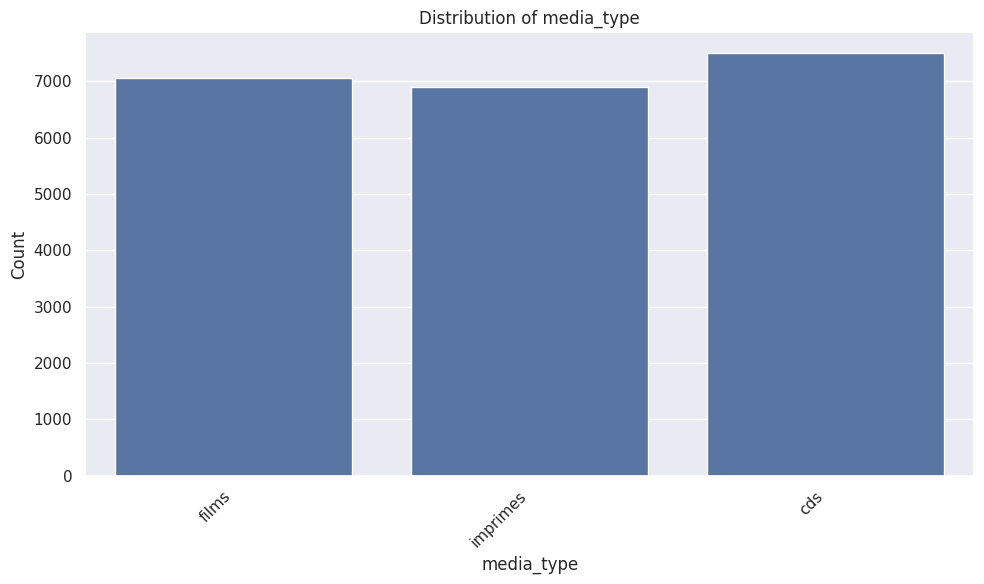

Value counts for title:
title
Alice au pays des merveilles                    23
Peter Pan                                       19
Le livre de la jungle                           17
Dumbo                                           16
D'une île à l'autre... : Chants et berceuses    14
                                                ..
Elior                                            1
View with a room                                 1
A New kind of love                               1
Meva festa                                       1
Player non player                                1
Name: count, Length: 9458, dtype: int64

Value counts for author:
author
-                           2458
Saint-Mars, Dominique de     293
Sobral, Patrick              228
Lyfoung, Patricia            184
Midam                        135
                            ... 
Spiritualized                  1
Orlinski, Jakub Jozef CT       1
Jones, Keziah                  1
David, Mack                    1
El Cig

In [17]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

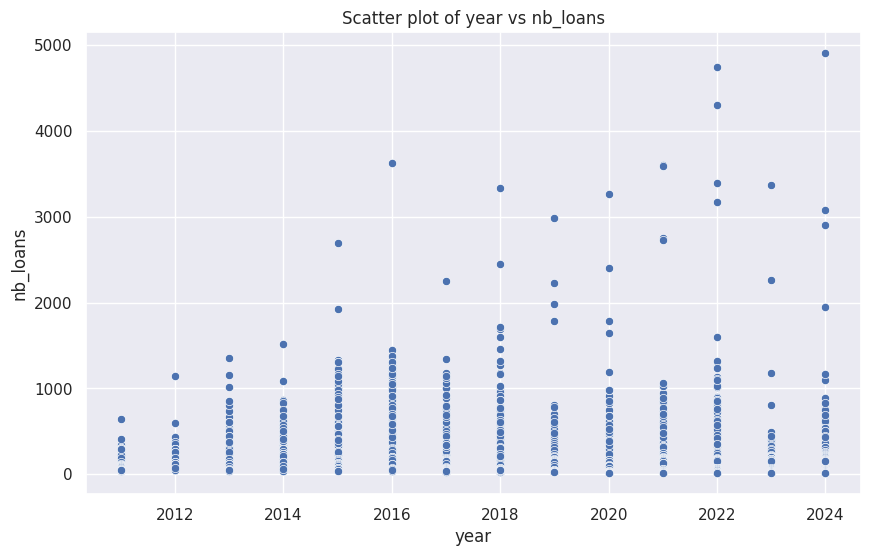

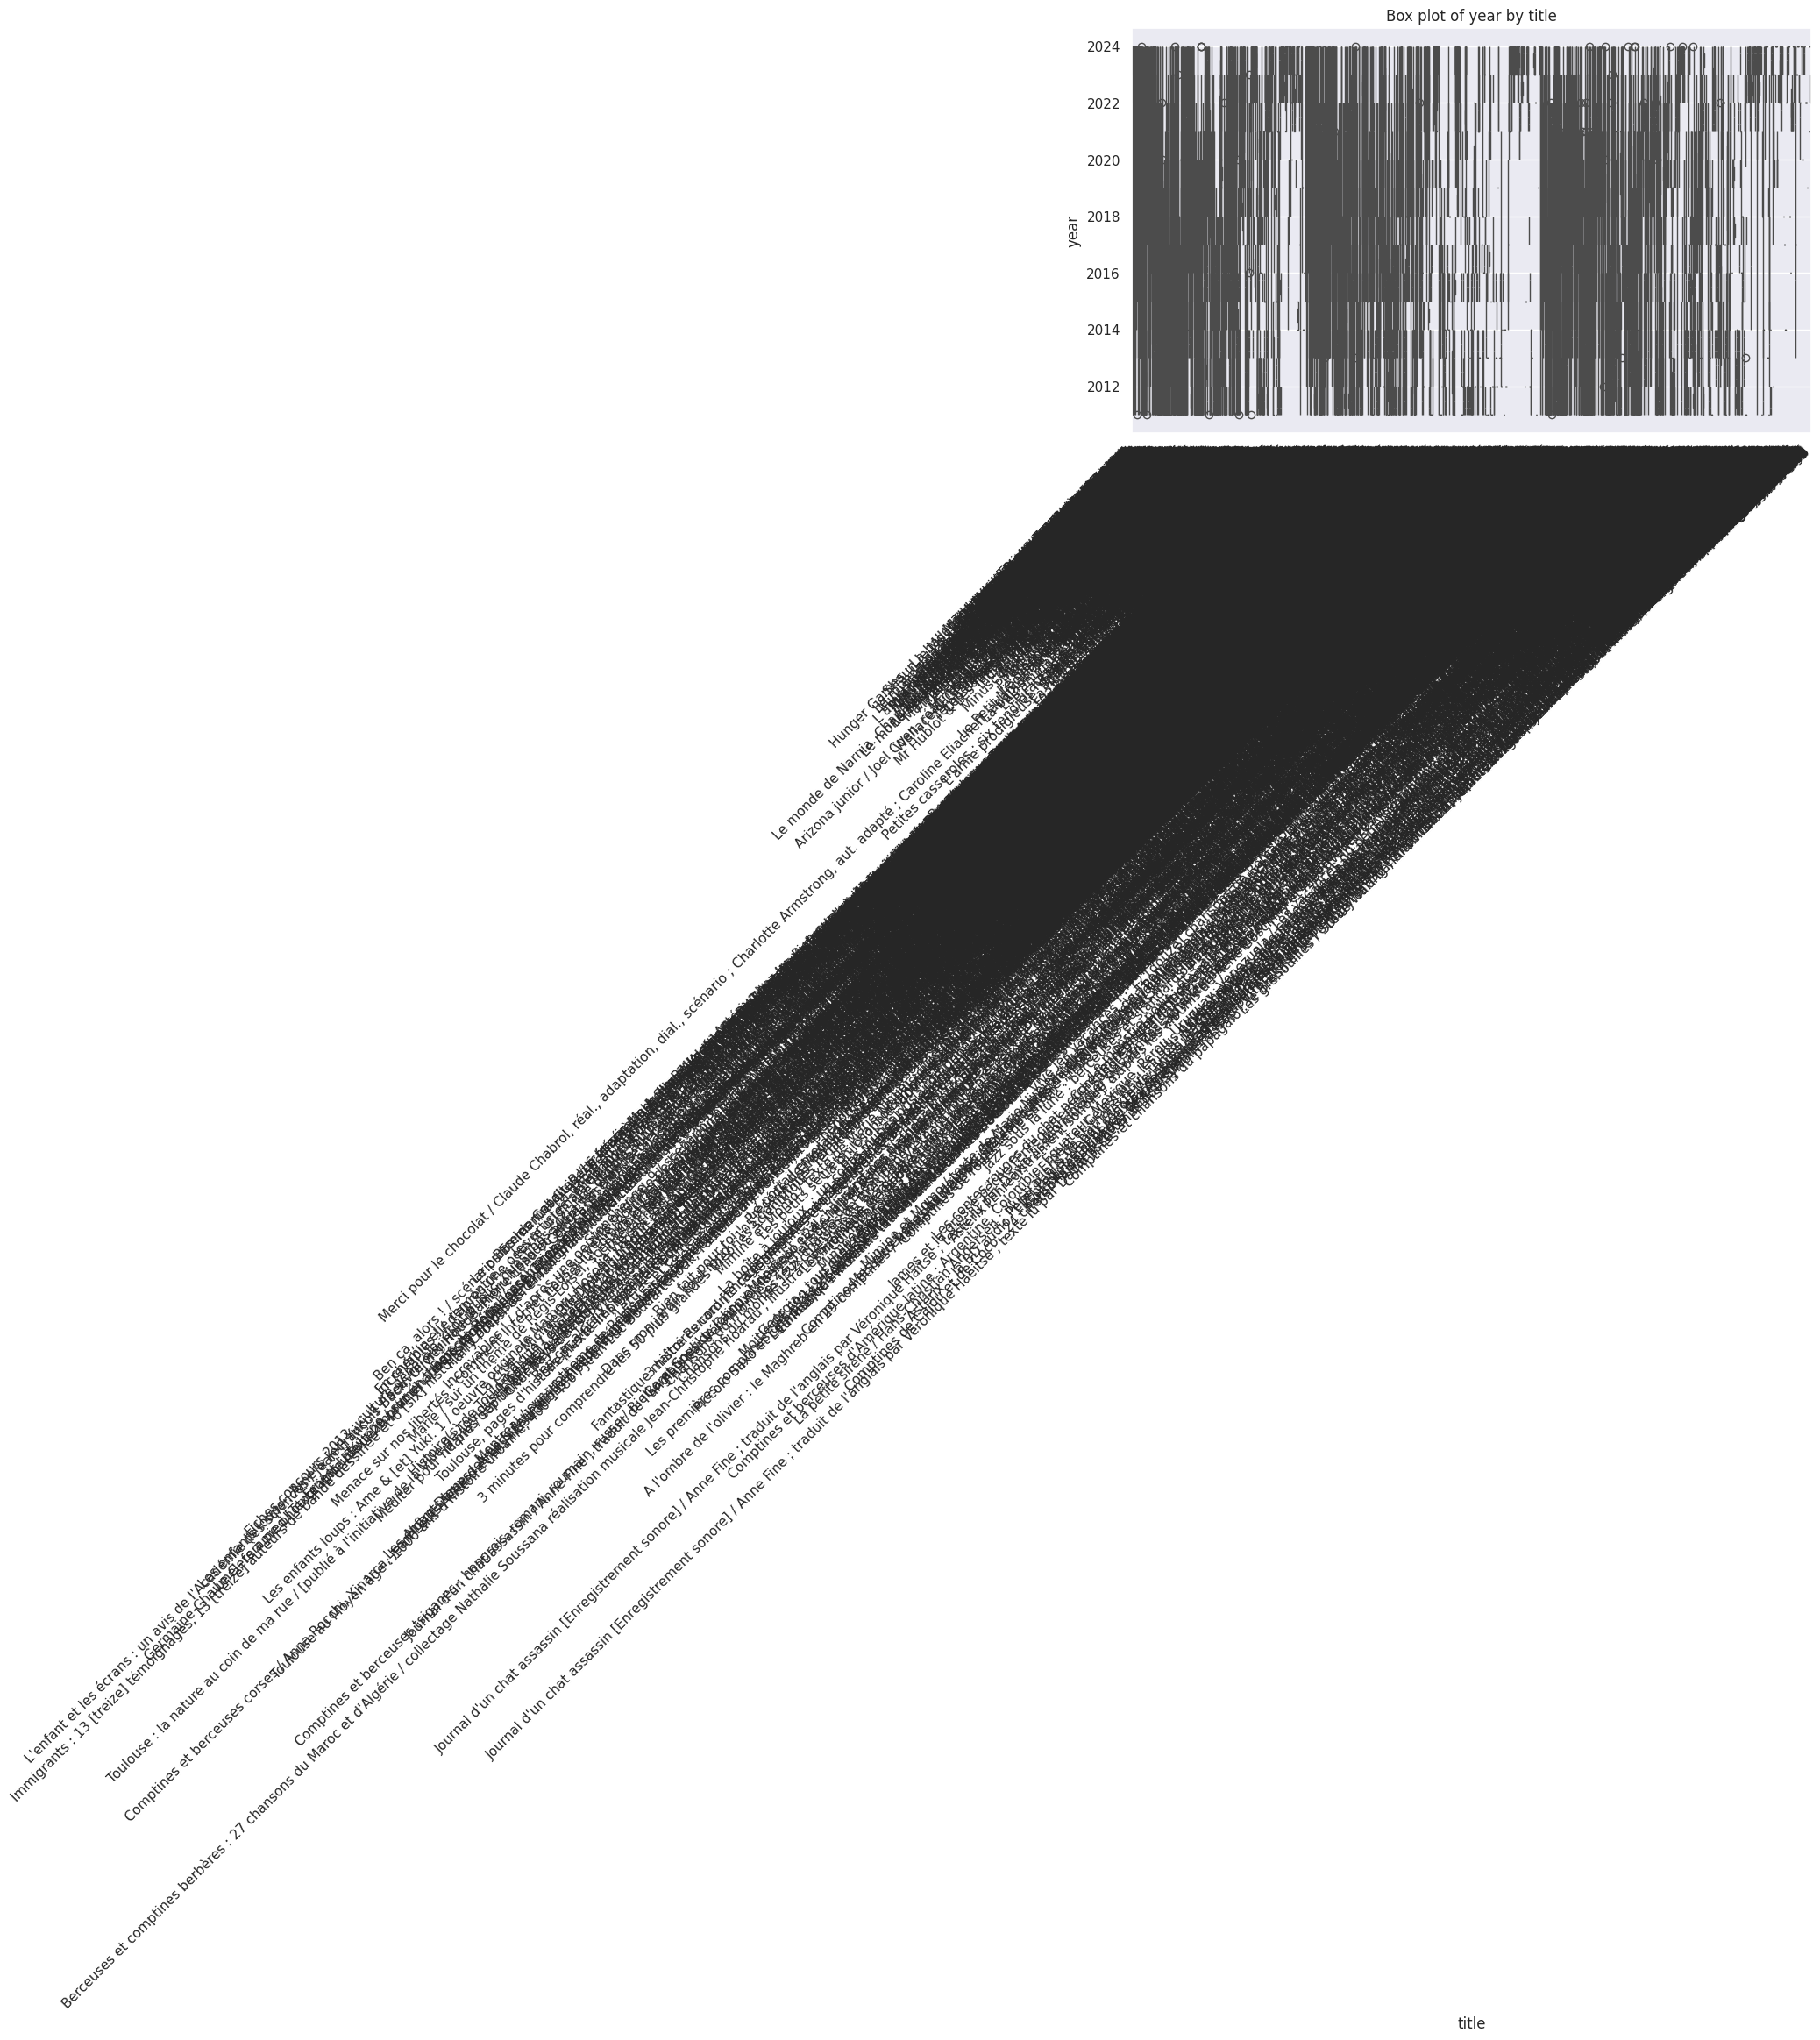

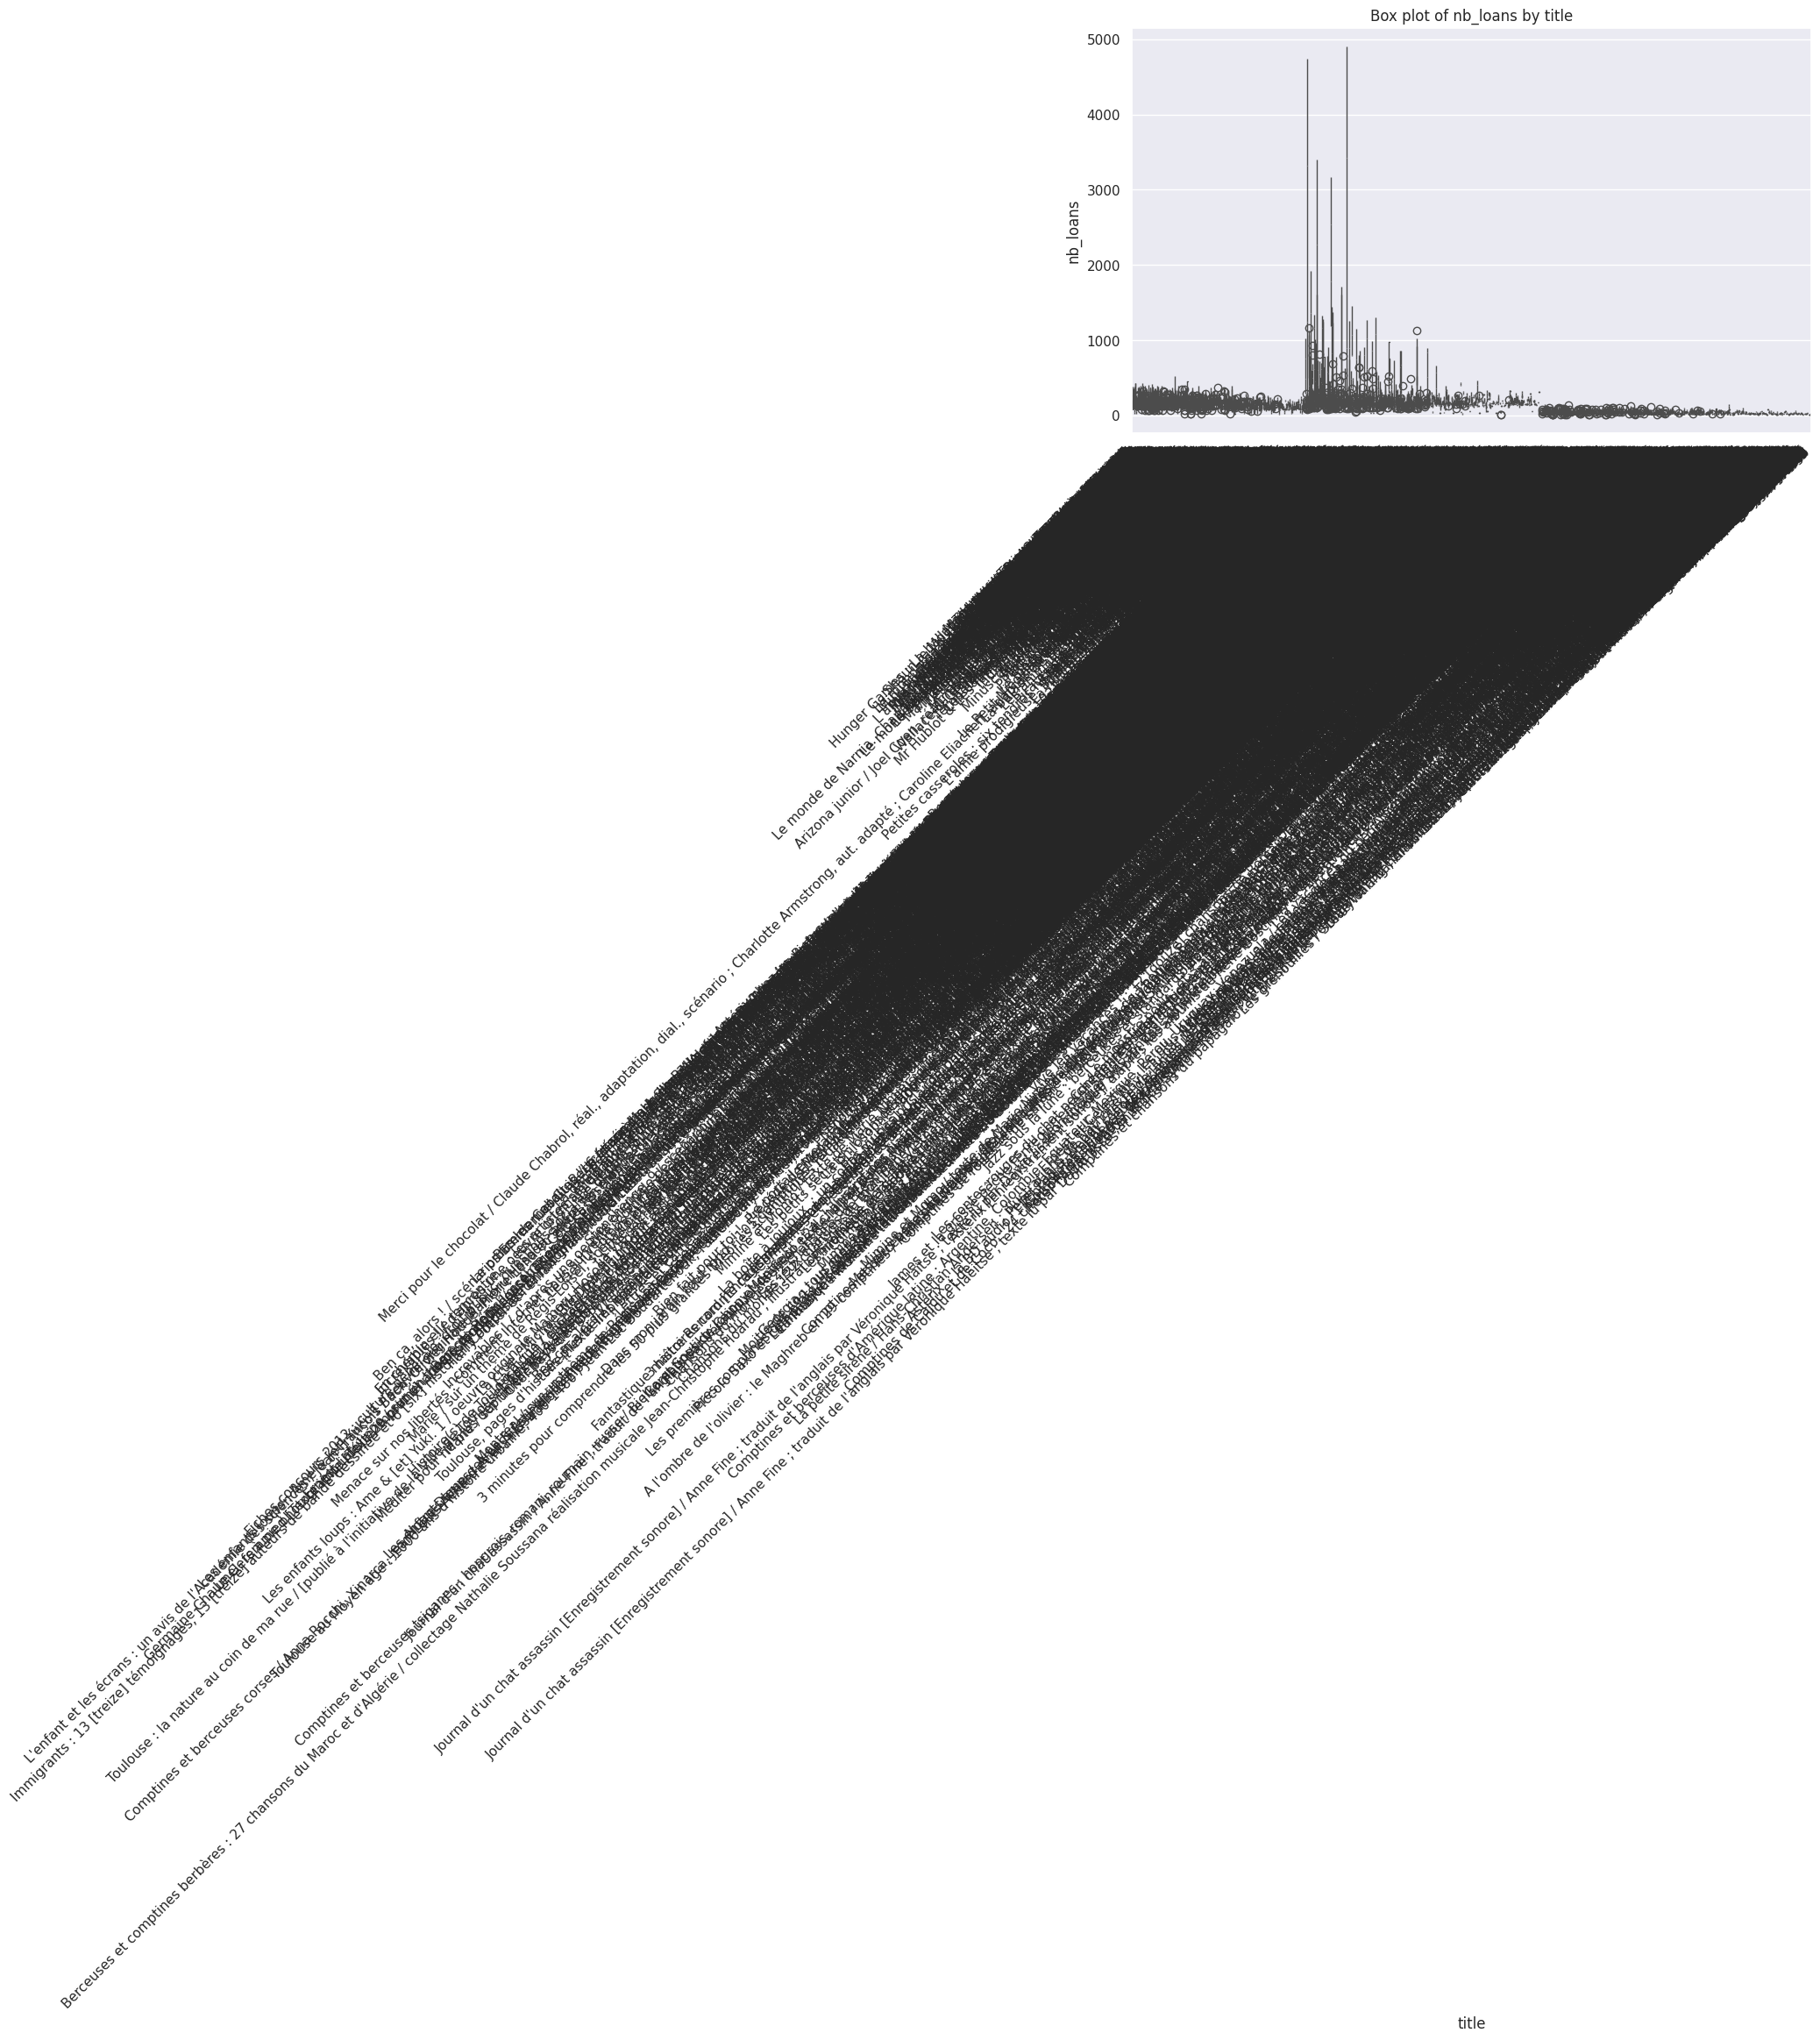

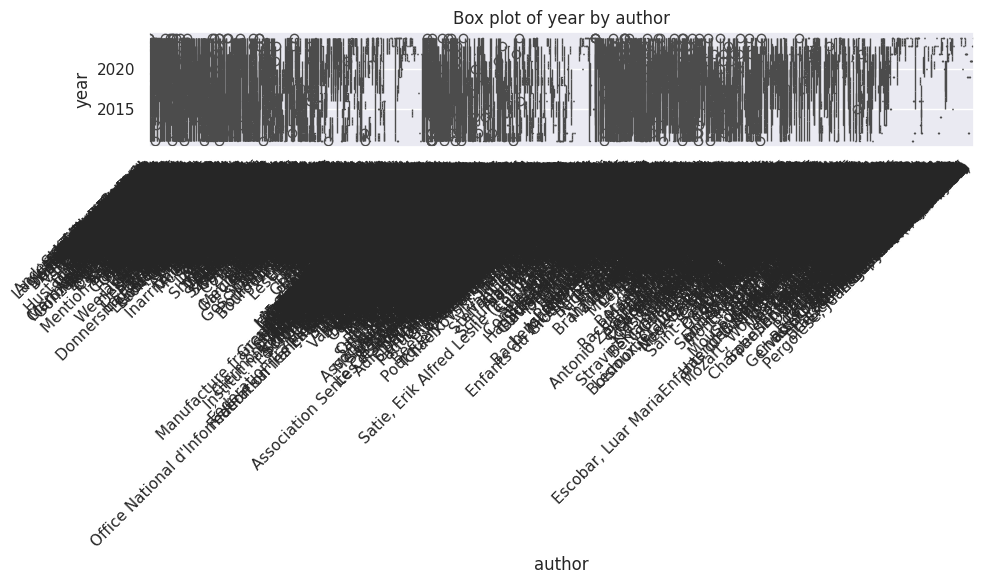

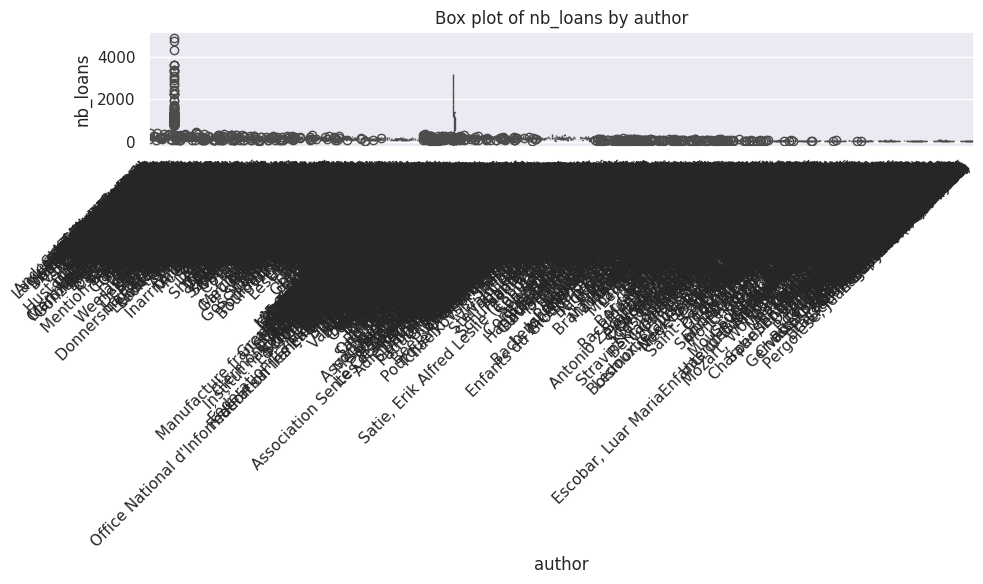

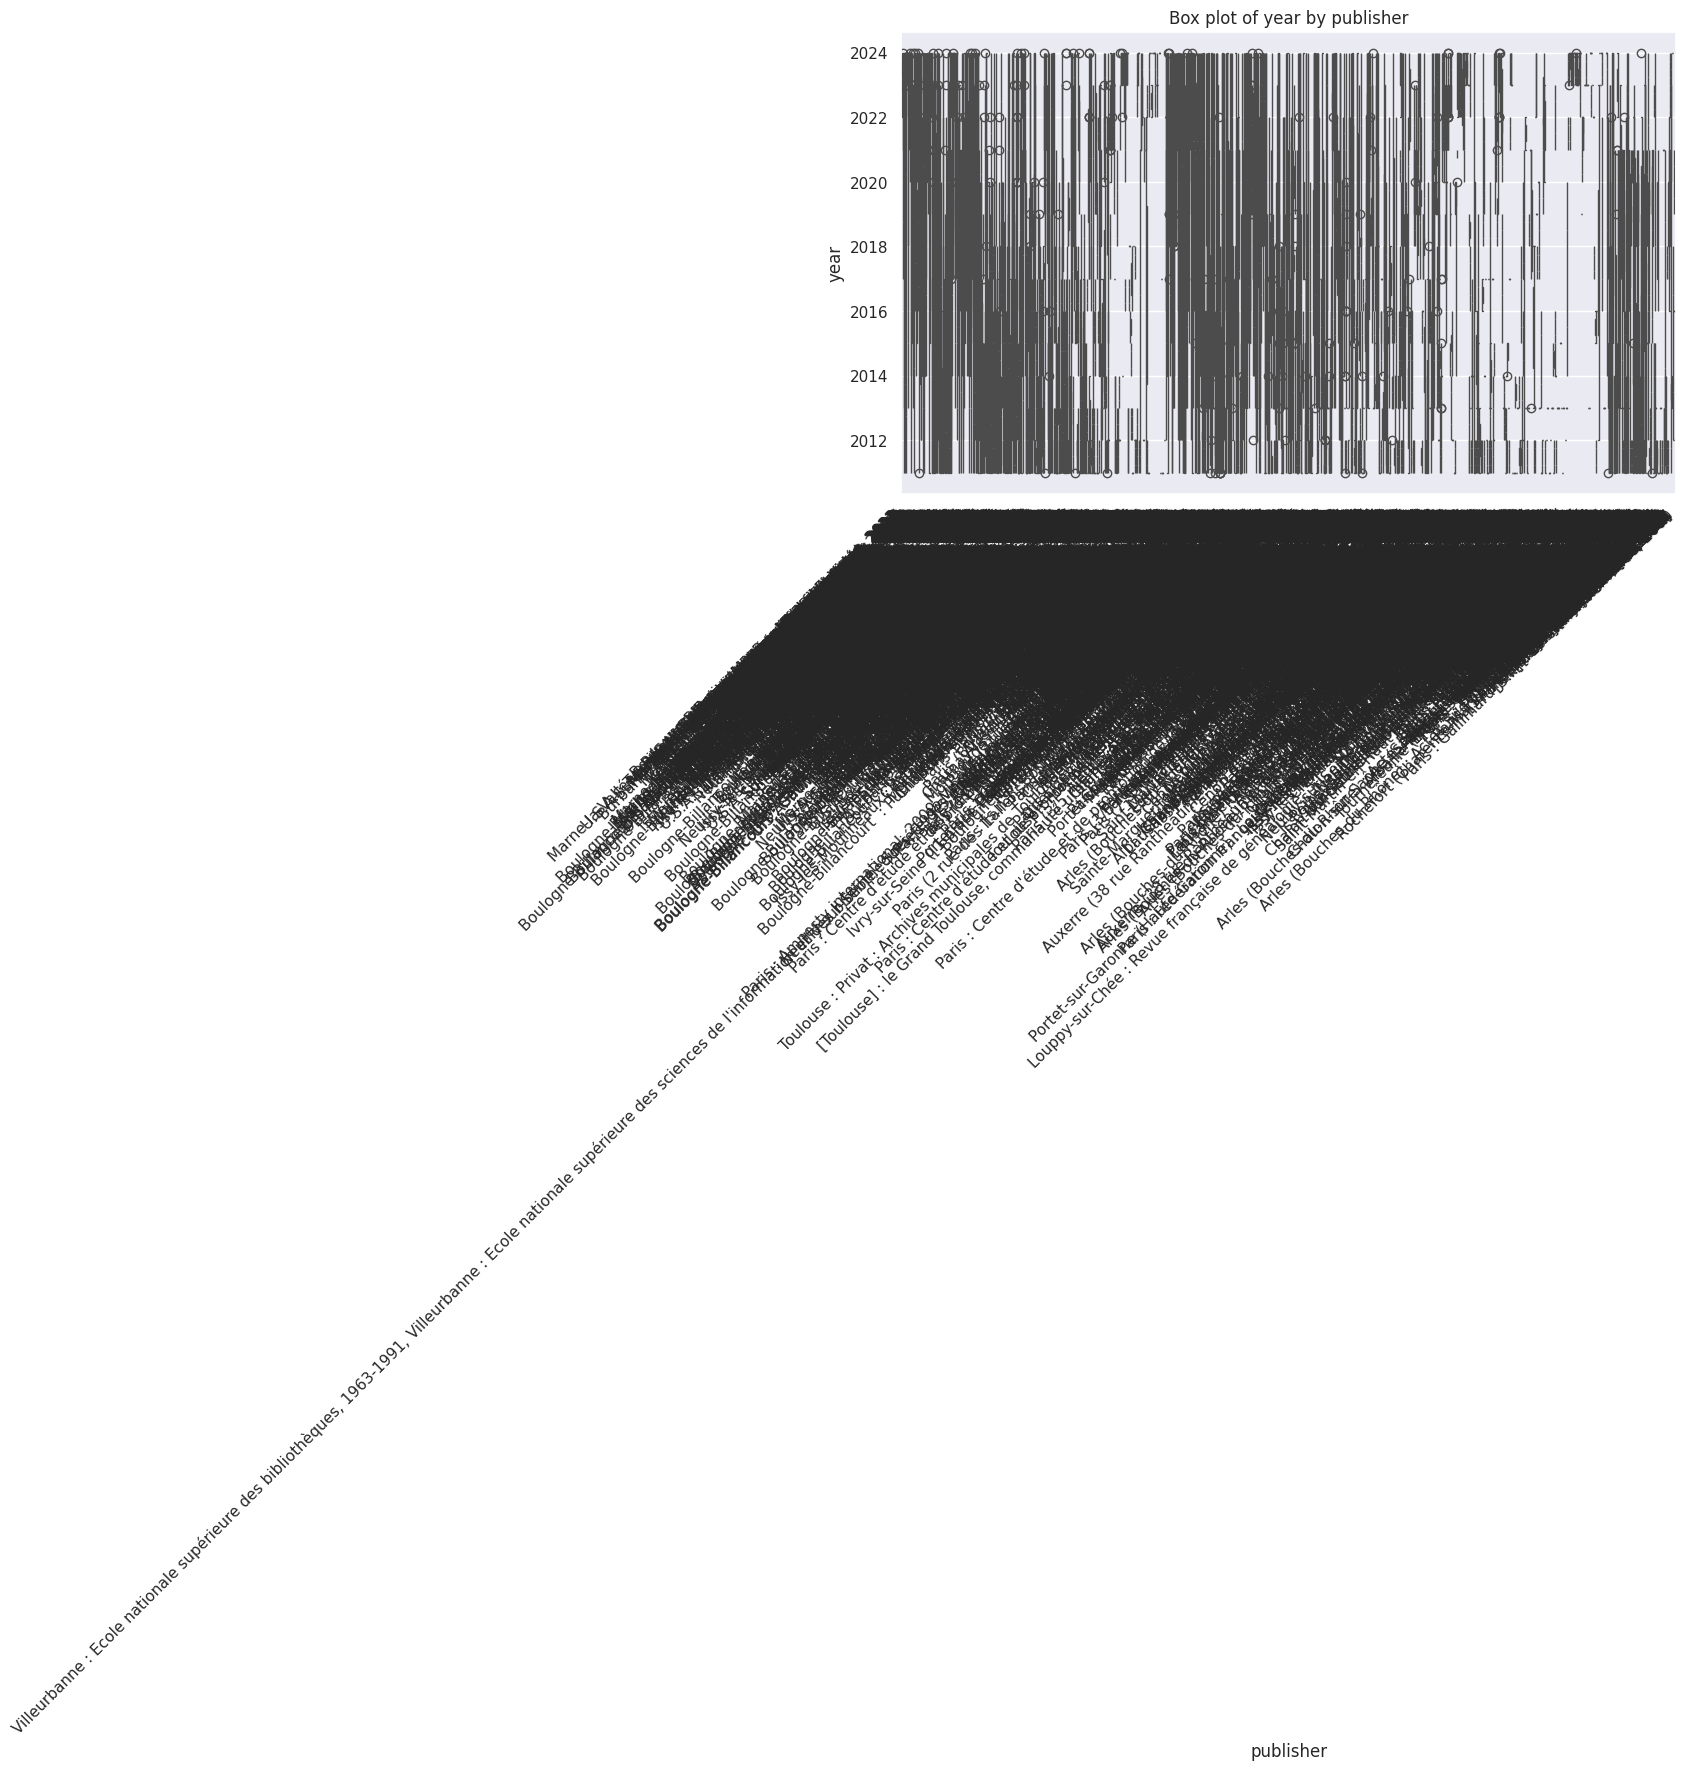

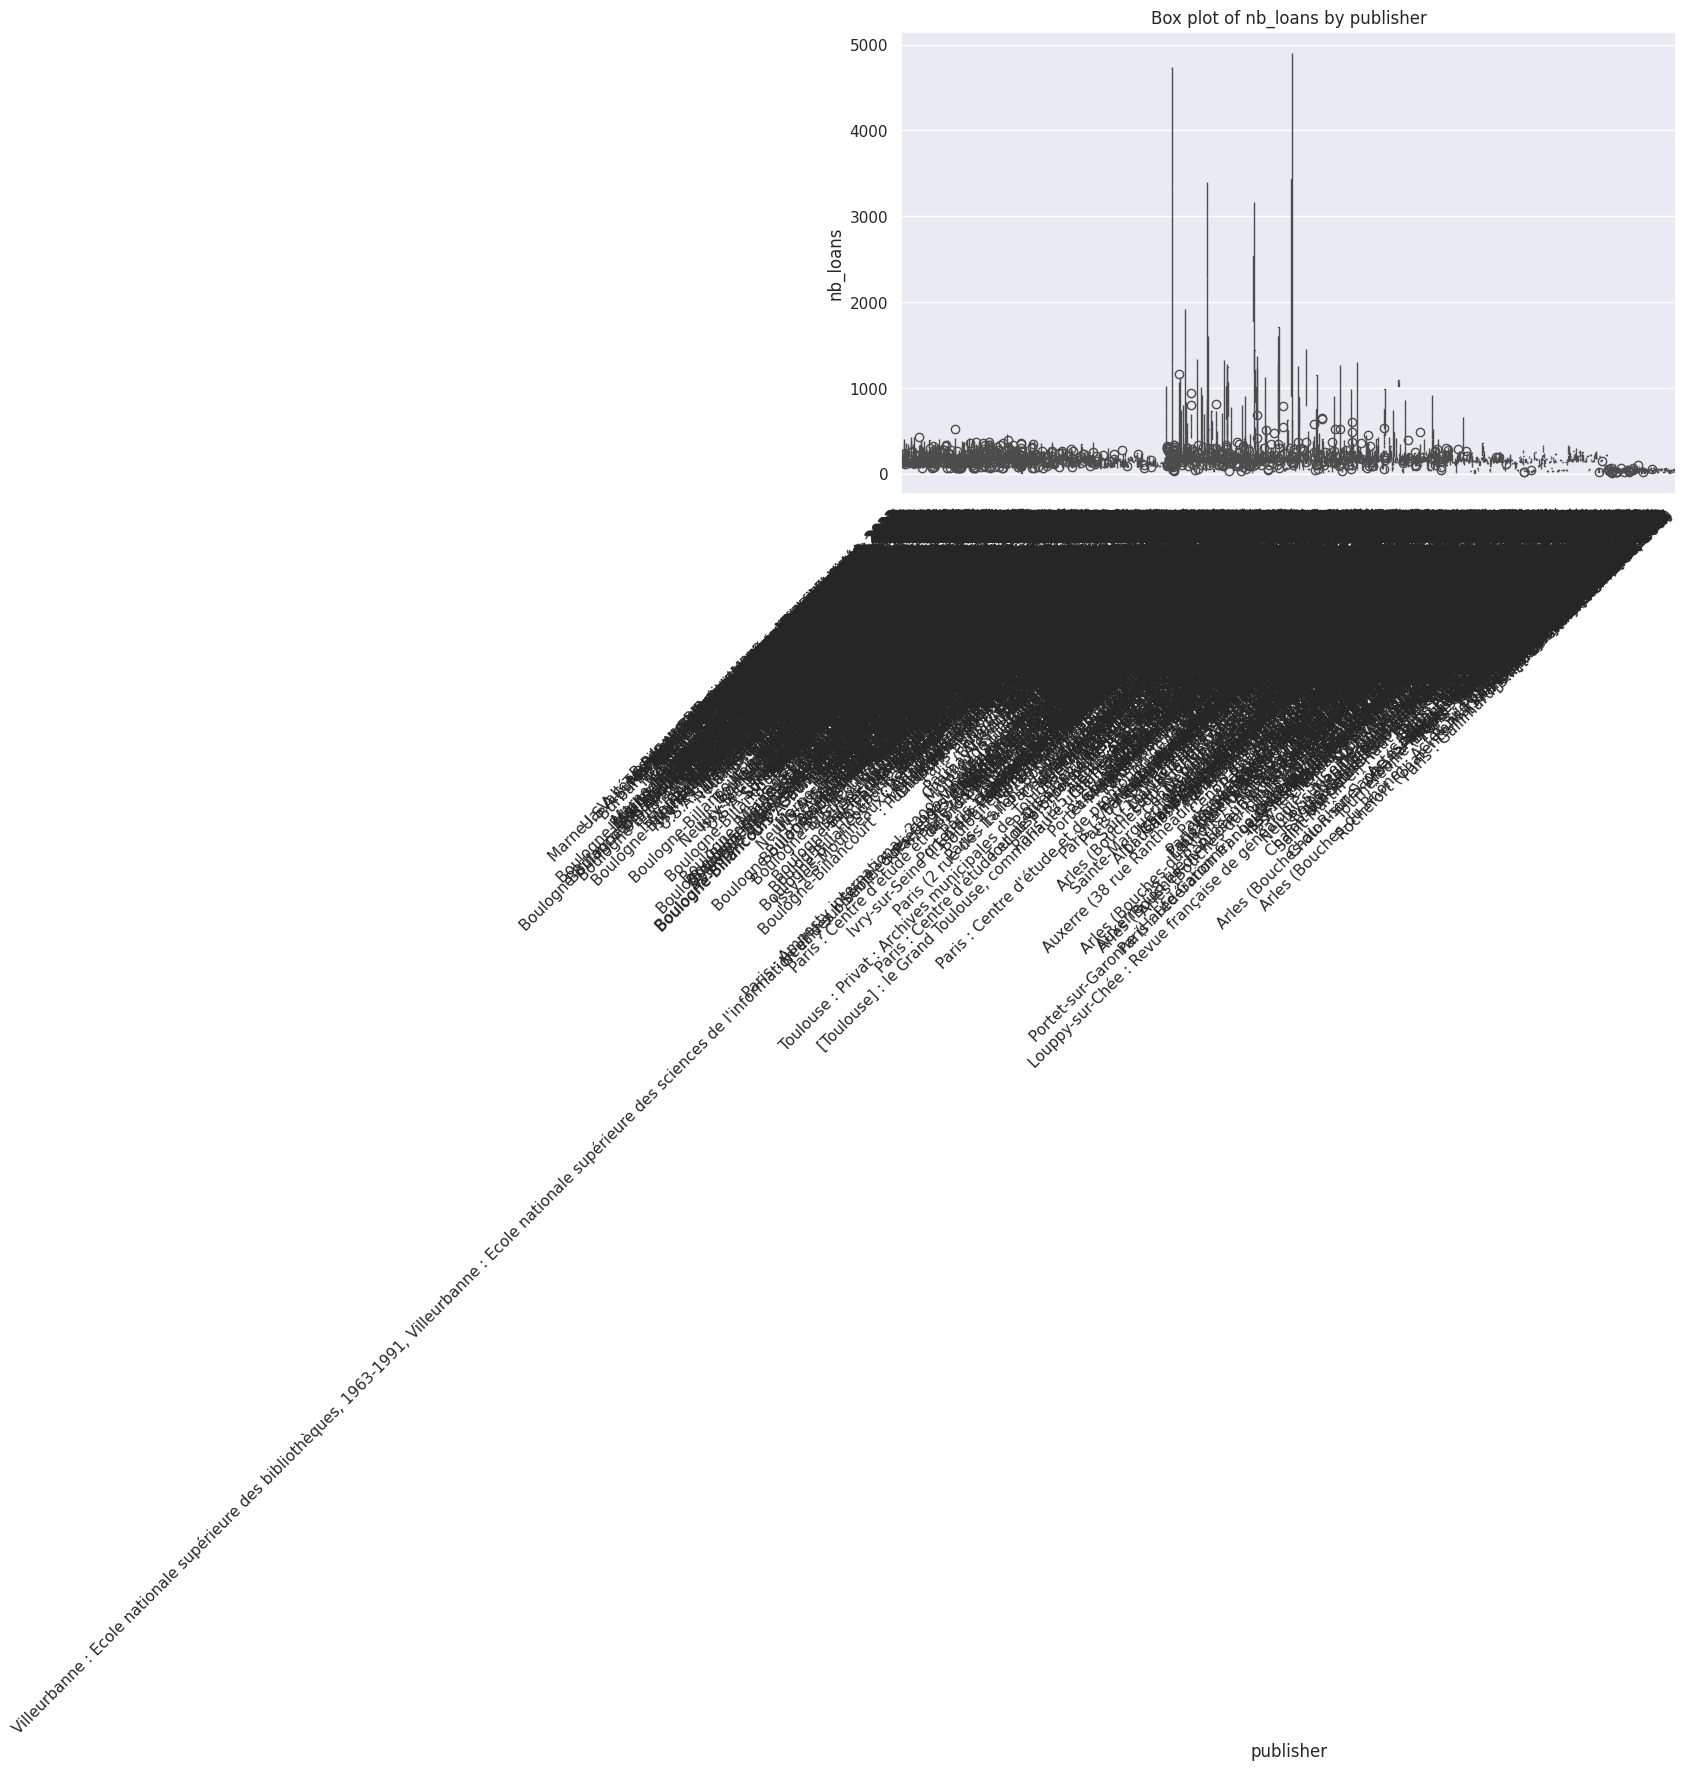

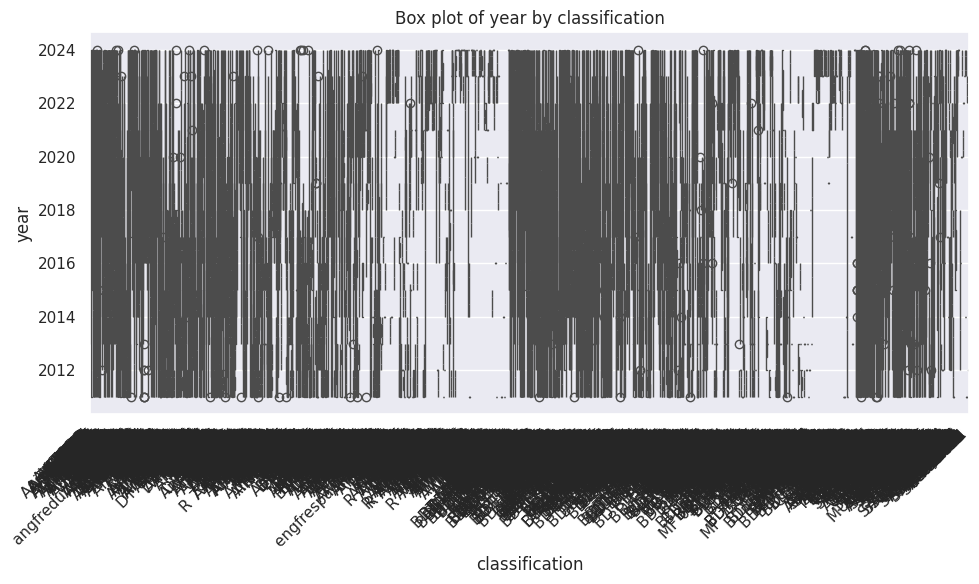

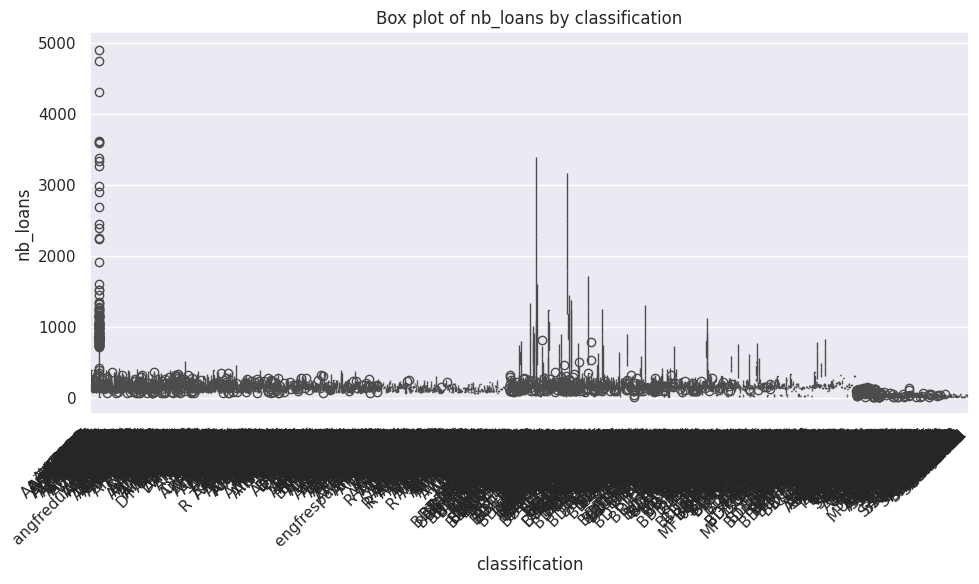

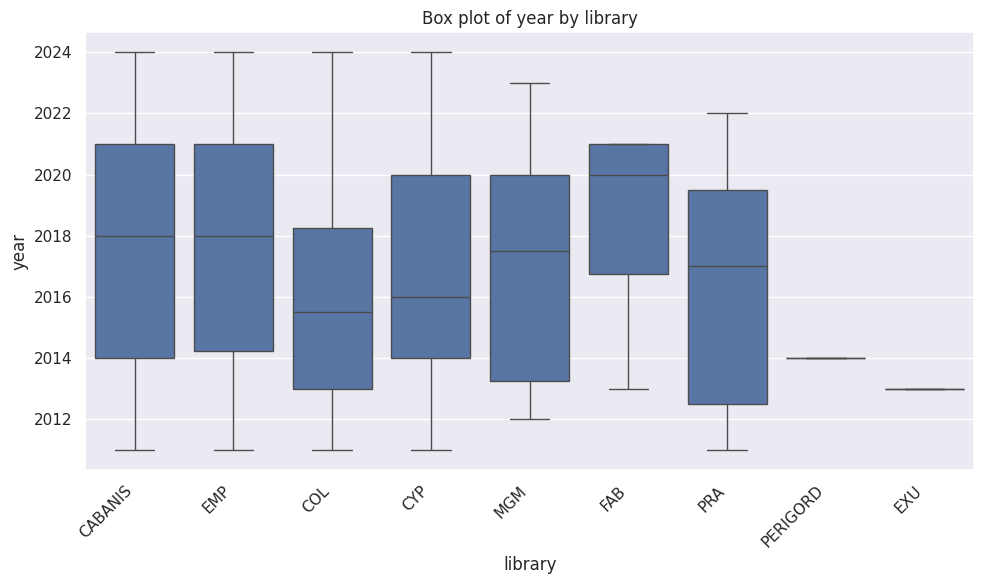

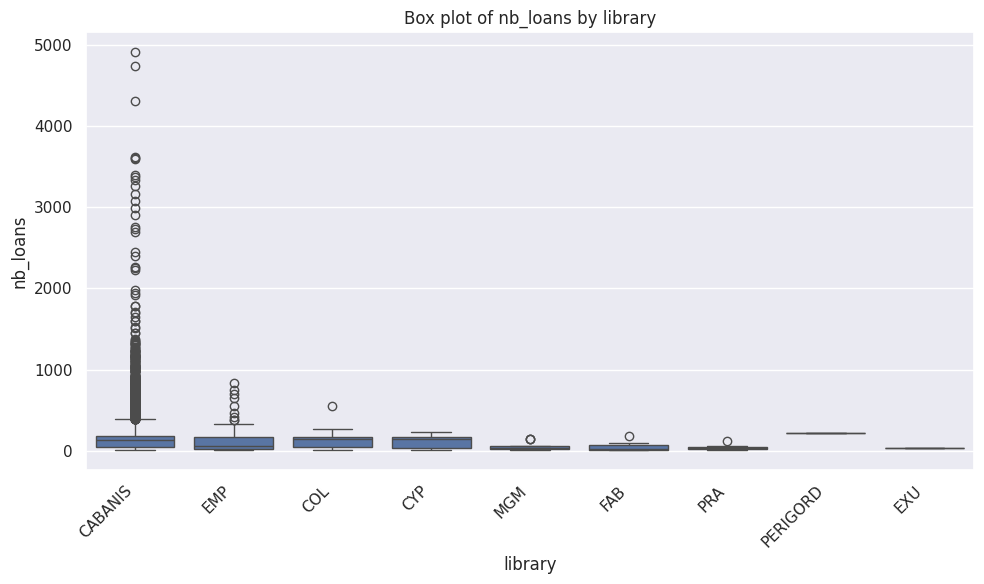

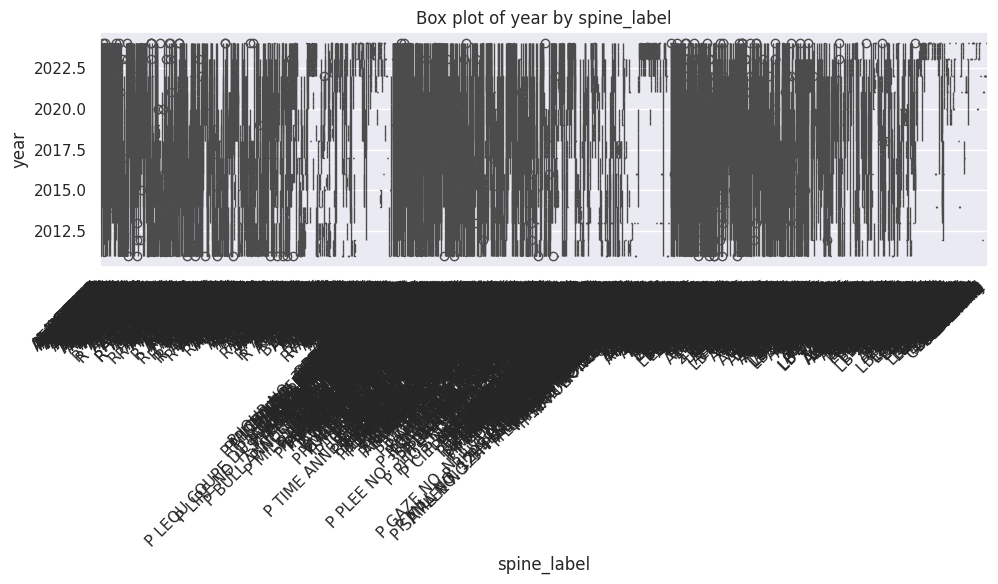

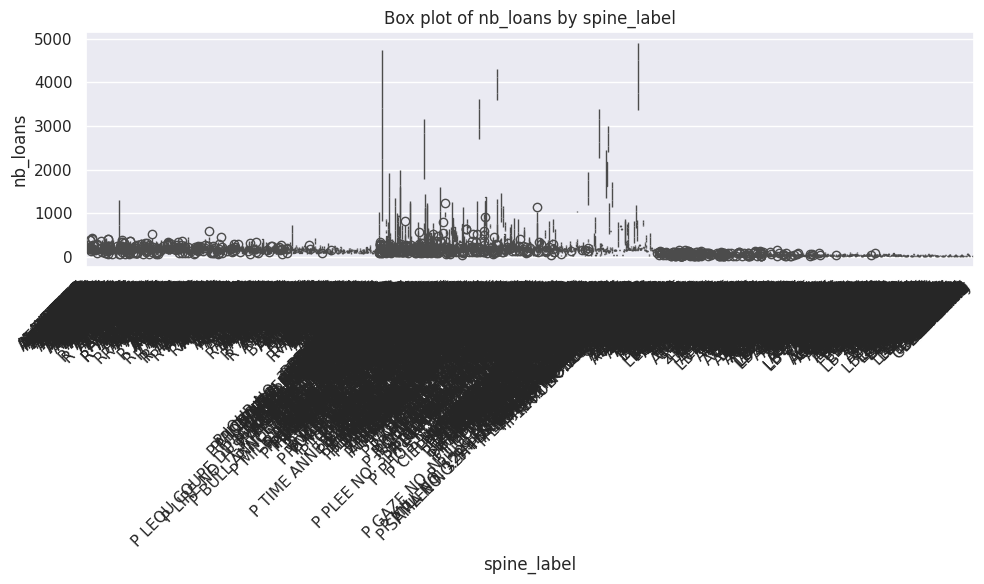

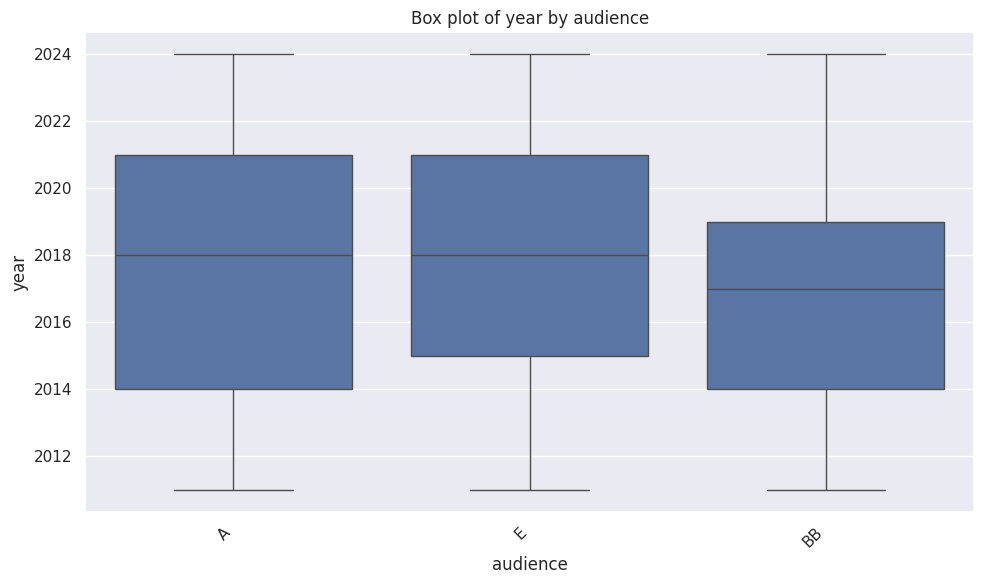

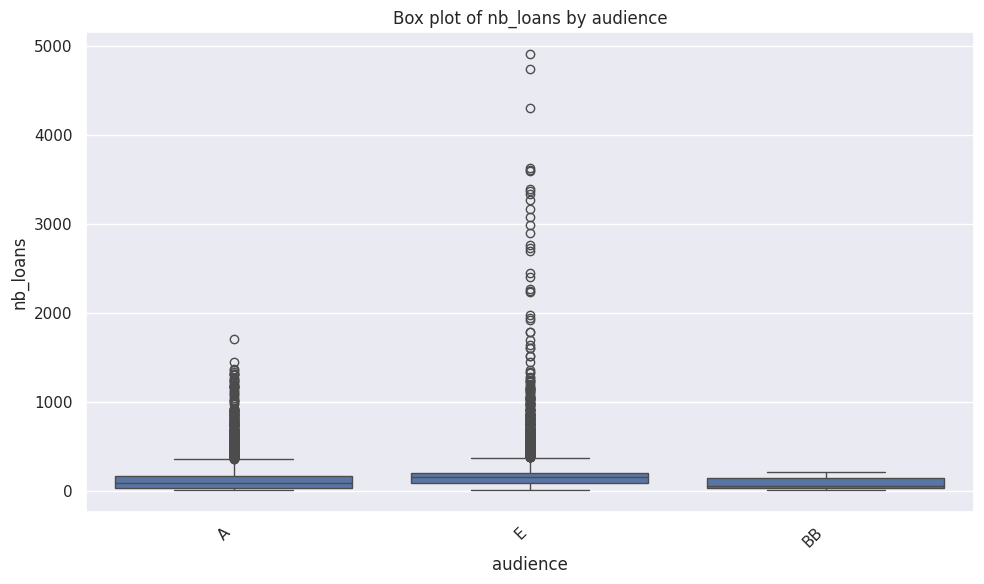

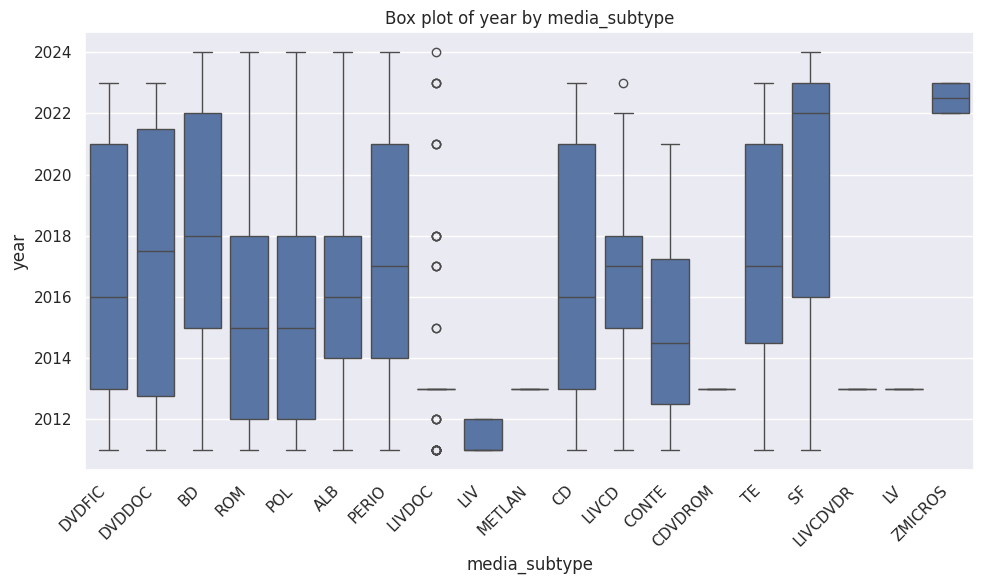

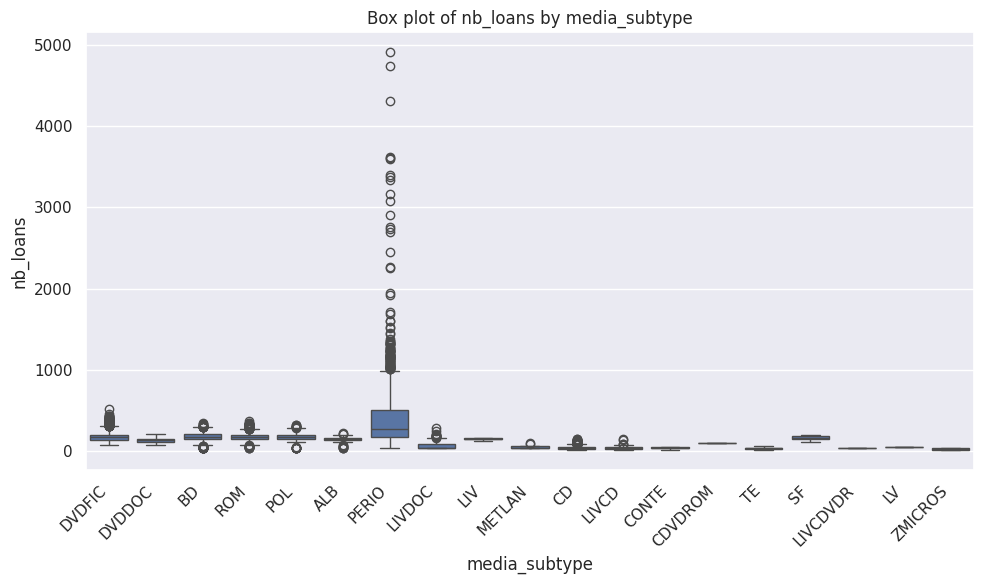

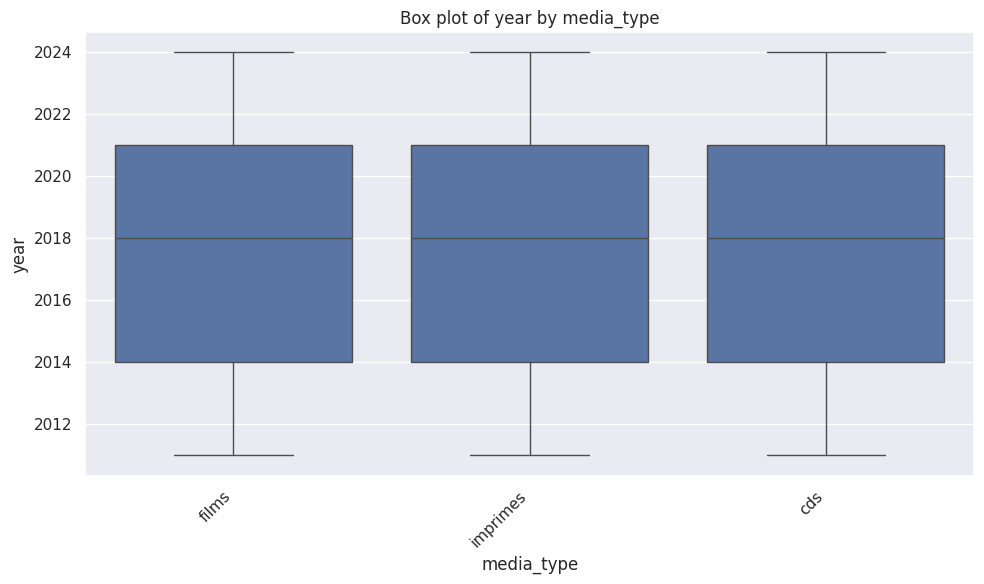

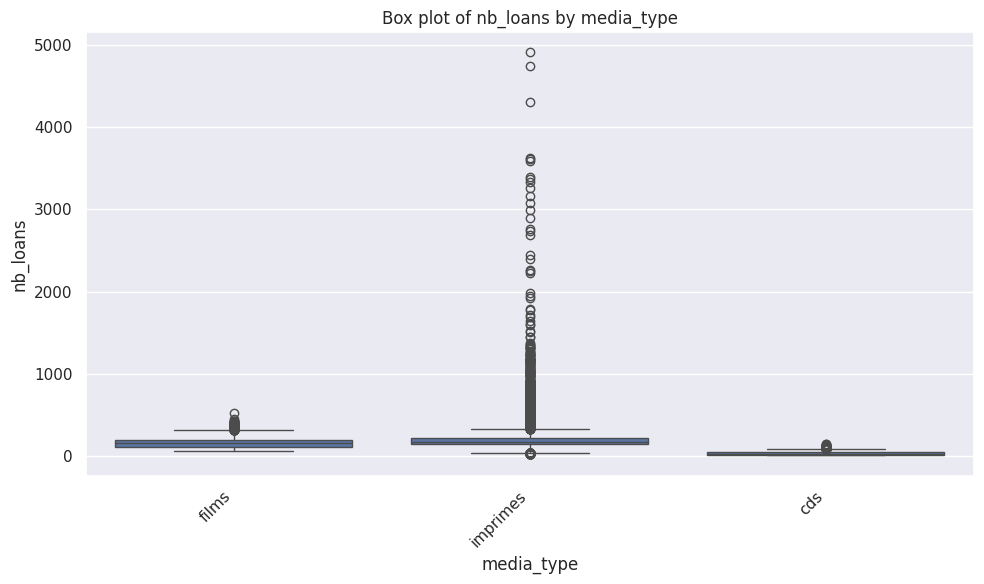

In [18]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

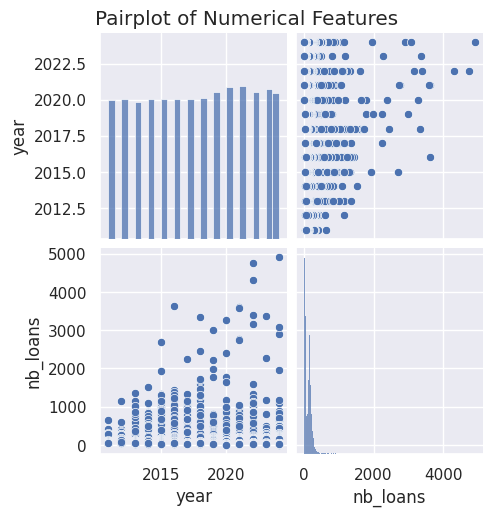

In [19]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

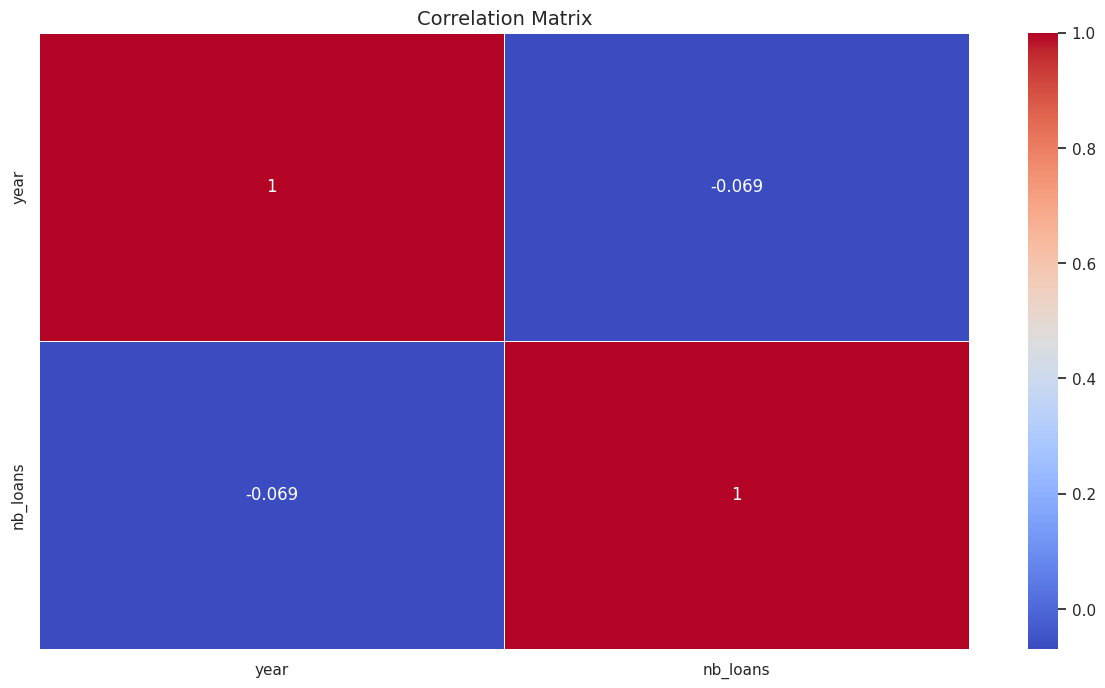

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You